# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 58    |  |
| :-------------|:-------------|
| Oscar Wesdorp| 6578365|
|Luuk van Dijk| 6518702|
|Jan van de Poll| 6527590|
|Jochem van den Boomen| 6527620|

In [ ]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Oscar Wesdorp']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="fotocalibratie" width="400">

Fit parameter:
a = 0.03404387545833065


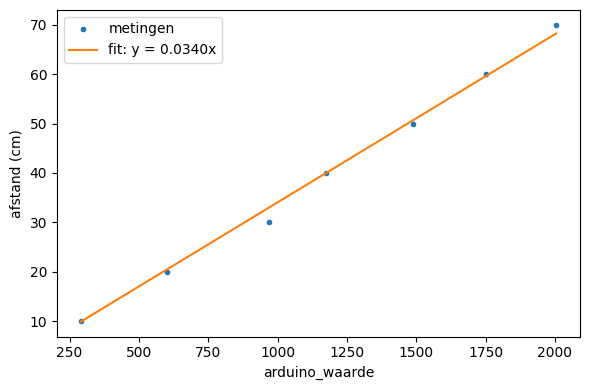

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
arduino_waarde = np.array([970, 290, 600, 1175, 1490, 1750, 2005])
afstand = np.array([30, 10, 20, 40, 50, 60, 70])

def lineair_0(x, a):
    return a * x

params, cov = curve_fit(lineair_0, arduino_waarde, afstand)
a = params[0]
print("Fit parameter:")
print(f"a = {a}")

plt.figure(figsize=(6,4))
plt.plot(arduino_waarde, afstand, '.', label='metingen')

x_line = np.linspace(min(arduino_waarde), max(arduino_waarde), 200)
y_line = lineair_0(x_line, a)
plt.plot(x_line, y_line, '-', label=f'fit: y = {a:.4f}x')

plt.xlabel('arduino_waarde')
plt.ylabel('afstand (cm)')
plt.legend()
plt.tight_layout()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  43
1   0  30   0  20  43
2   0  10   0  20  51
3  40   0  30   0  42
4  30   0  20   0  42


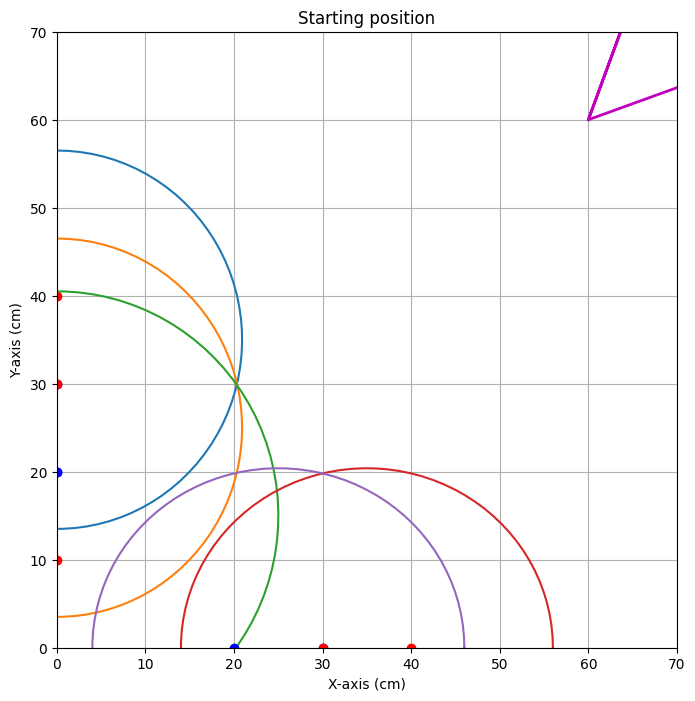


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.766


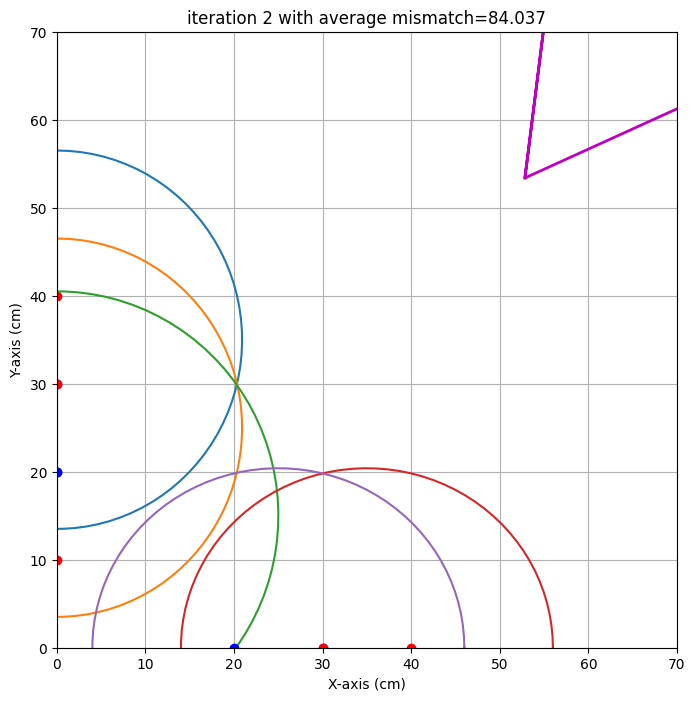

end iteration 2 with average mismatch=84.037


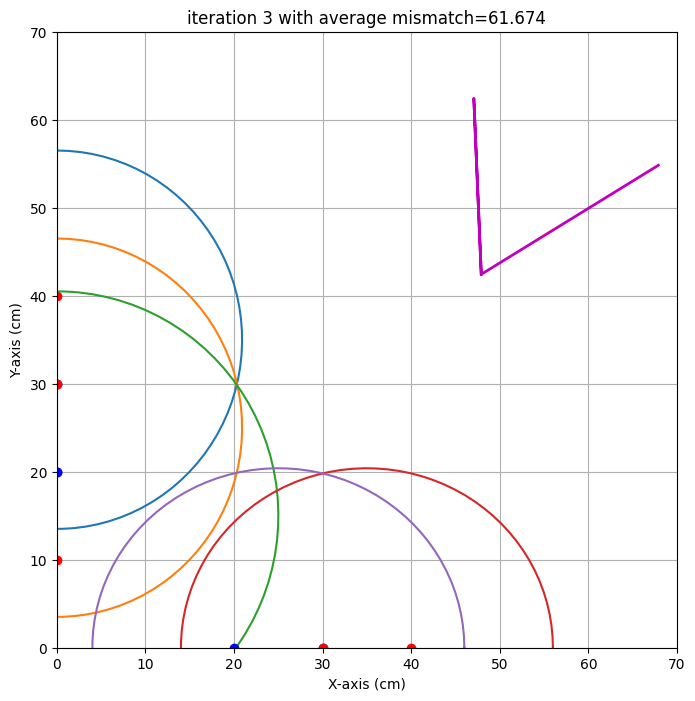

end iteration 3 with average mismatch=61.674


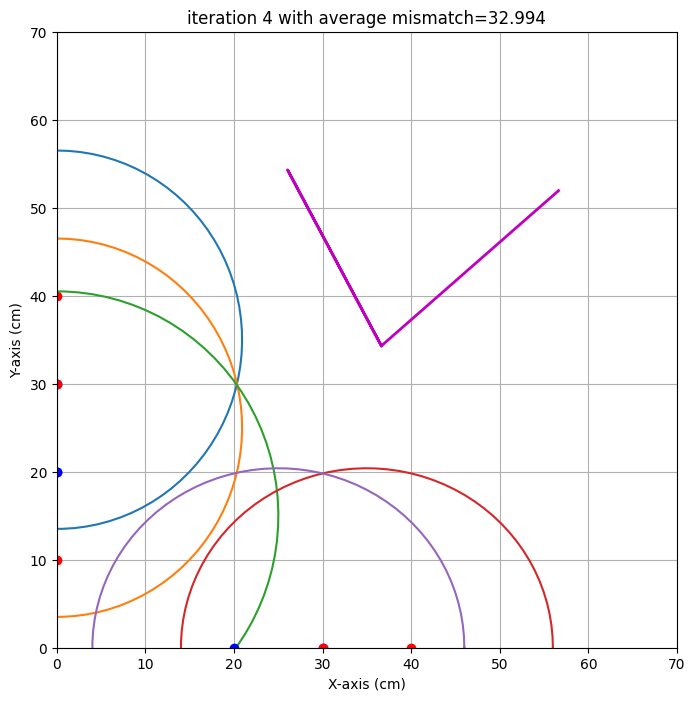

end iteration 4 with average mismatch=32.994


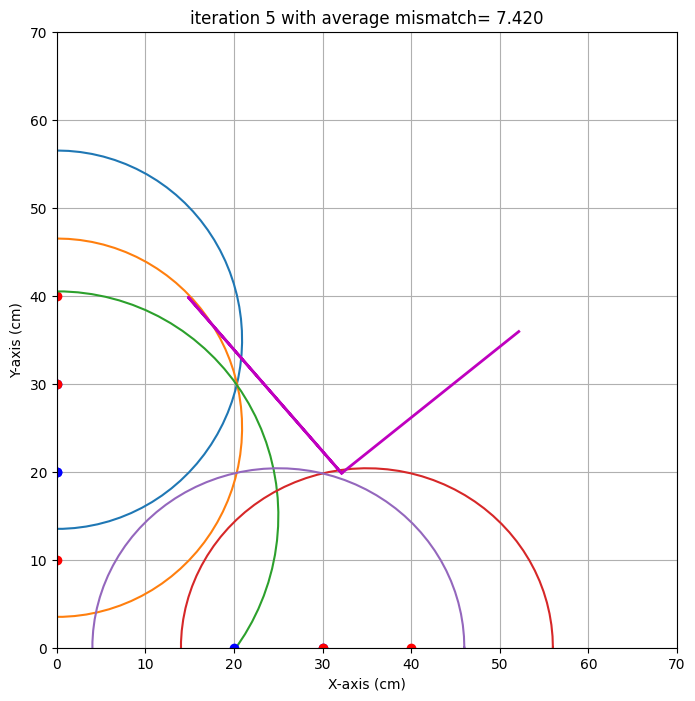

end iteration 5 with average mismatch= 7.420


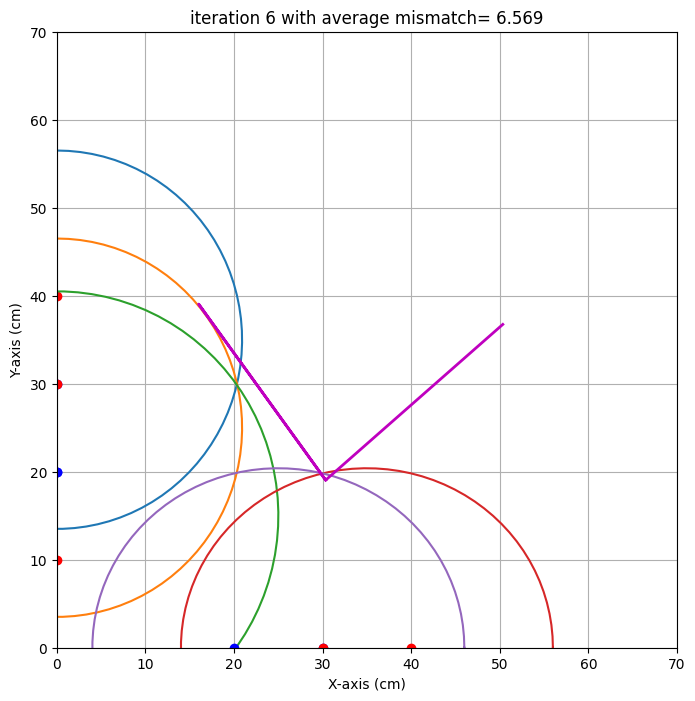

end iteration 6 with average mismatch= 6.569


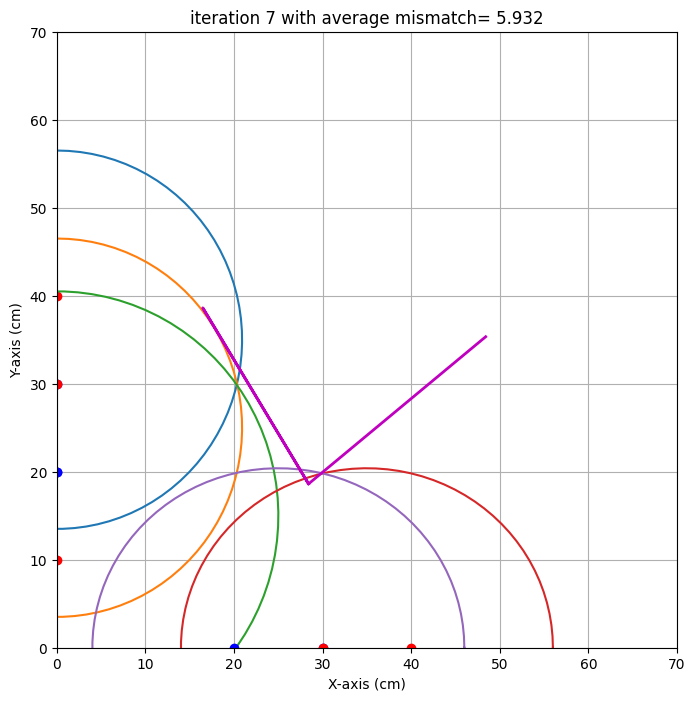

end iteration 7 with average mismatch= 5.932


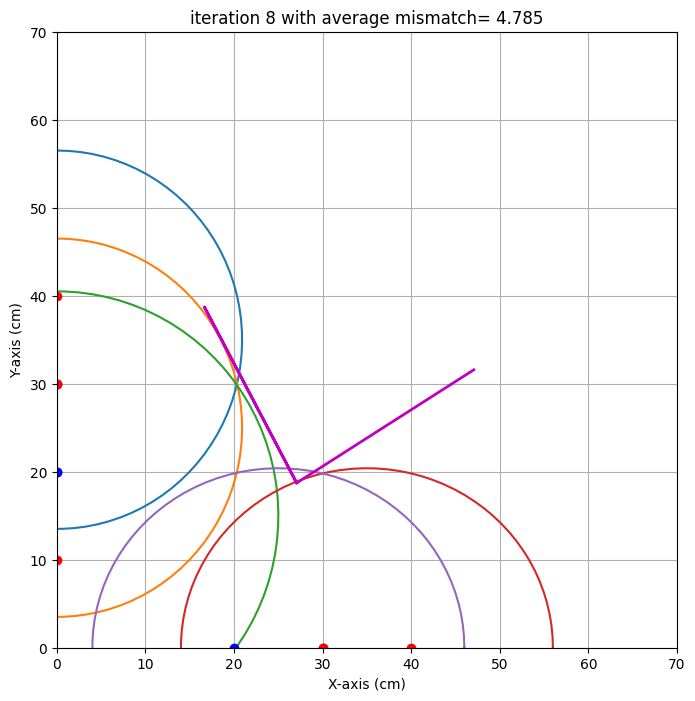

end iteration 8 with average mismatch= 4.785


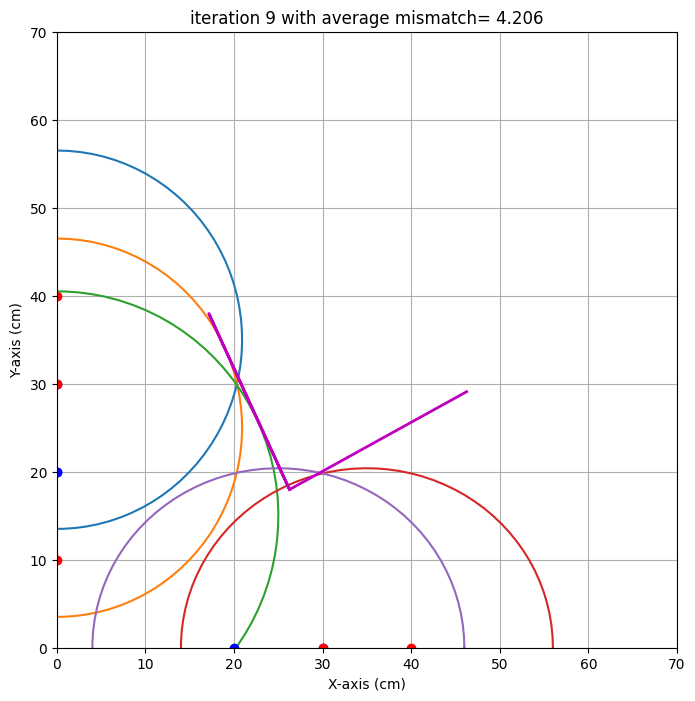

end iteration 9 with average mismatch= 4.206


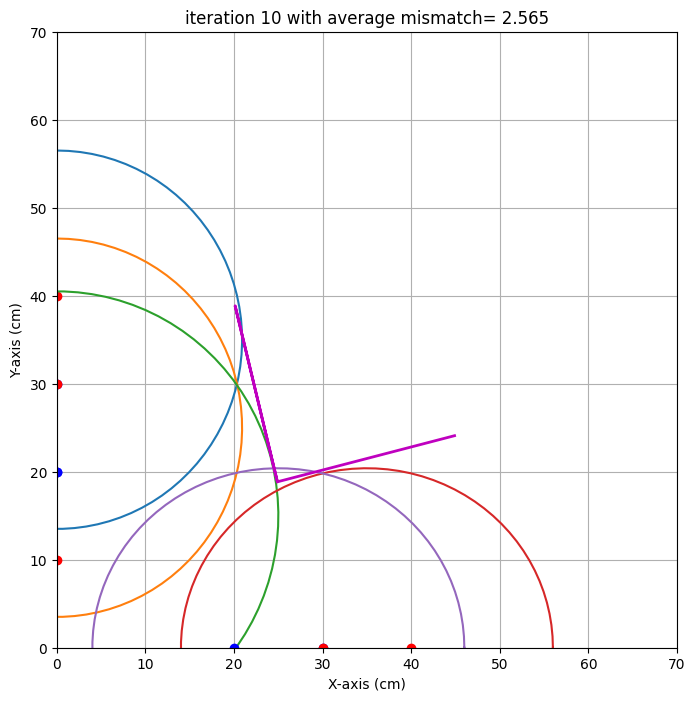

end iteration 10 with average mismatch= 2.565
end iteration 11 with average mismatch= 2.477
end iteration 12 with average mismatch= 2.402


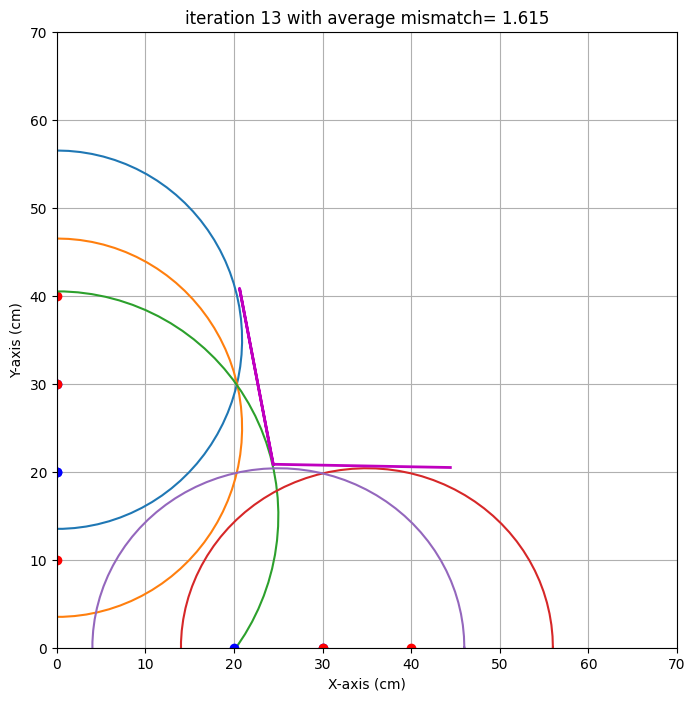

end iteration 13 with average mismatch= 1.615


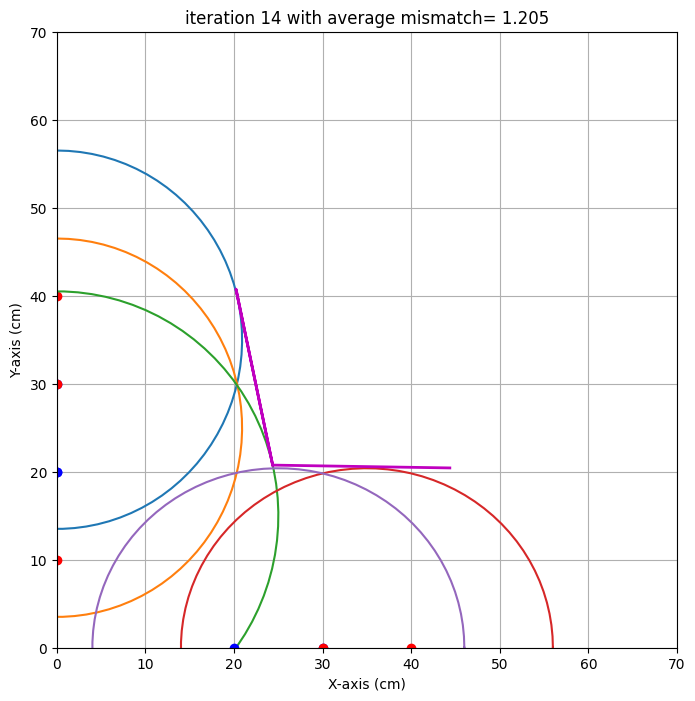

end iteration 14 with average mismatch= 1.205
end iteration 15 with average mismatch= 1.166
end iteration 16 with average mismatch= 1.165
end iteration 17 with average mismatch= 1.164
end iteration 18 with average mismatch= 1.164
end iteration 19 with average mismatch= 1.164
end iteration 20 with average mismatch= 1.164
end iteration 21 with average mismatch= 1.164
end iteration 22 with average mismatch= 1.137
end iteration 23 with average mismatch= 1.090
end iteration 24 with average mismatch= 1.072
end iteration 25 with average mismatch= 1.071
end iteration 26 with average mismatch= 1.071
end iteration 27 with average mismatch= 1.070
end iteration 28 with average mismatch= 1.070
end iteration 29 with average mismatch= 1.070
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.070
###########################################################

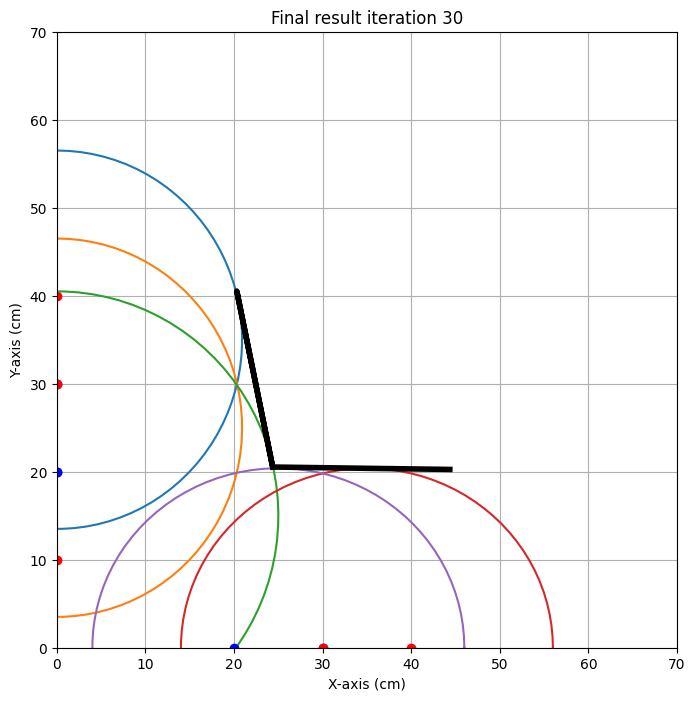

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.


dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43],
    [0,30,0,20,43],
    [0,10,0,20,51],
    [40,0,30,0,42],
    [30,0,20,0,42],
    #[10,0,20,0,85],
    #[10,0,0,10,104]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 24.4 cm met een standaardafwijking van 0.0 cm 
y0: 20.5 cm met een standaardafwijking van 0.0 cm 
alpha: -0.8 graden met een standaardafwijking van 0.0 graad 
beta: -11.5 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [naam eerste student]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam tweede student]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="tudelftLogo.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [20]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':45,  #zelf aanvullen,
           'y0':50,#zelf aanvullen,
           'alpha' :0, #zelf aanvullen,
           'beta' :-9, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'luuk' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    [20,0,70,0,110],
    [35,0,55,0,100],
    [0,50,0,60,86],
    [0,50,0,70,86],
    ]),
       'Oscar' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    [20,0,30,0,111],
    [30,0,40,0,102],
    [40,0,50,0,99],
    [50,0,60,0,98],
    [0,30,0,40,114],
    [0,40,0,50,89],
   [ 0,50,0,60,86]]),
       'Jochem' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #eerste meting reeel
    [55,0,65,0,97],
    [50,0,60,0,97],
    [0,55,0,65,86],
    [0,50,0,60,87]])
      }

## Opdracht 7: Evaluatie.

luuk
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  70   0  110
1  35   0  55   0  100
2   0  50   0  60   86
3   0  50   0  70   86


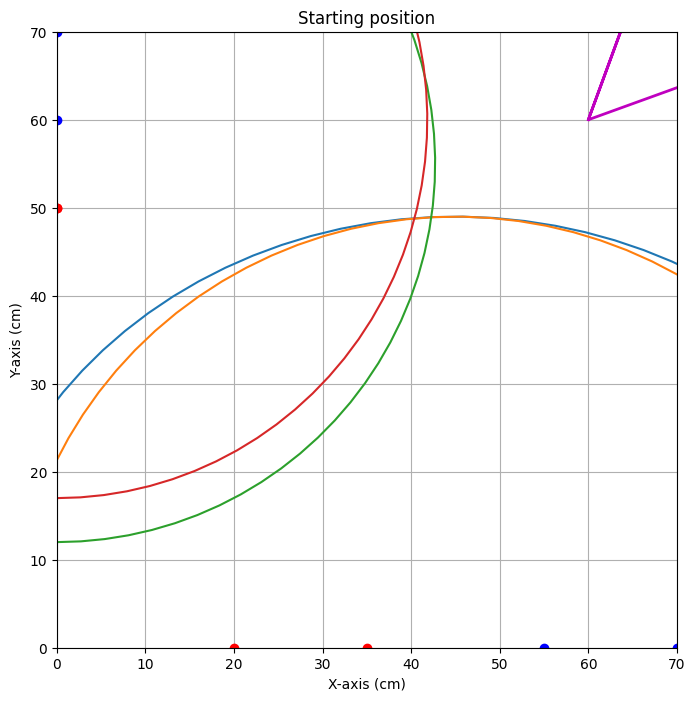


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=35.058


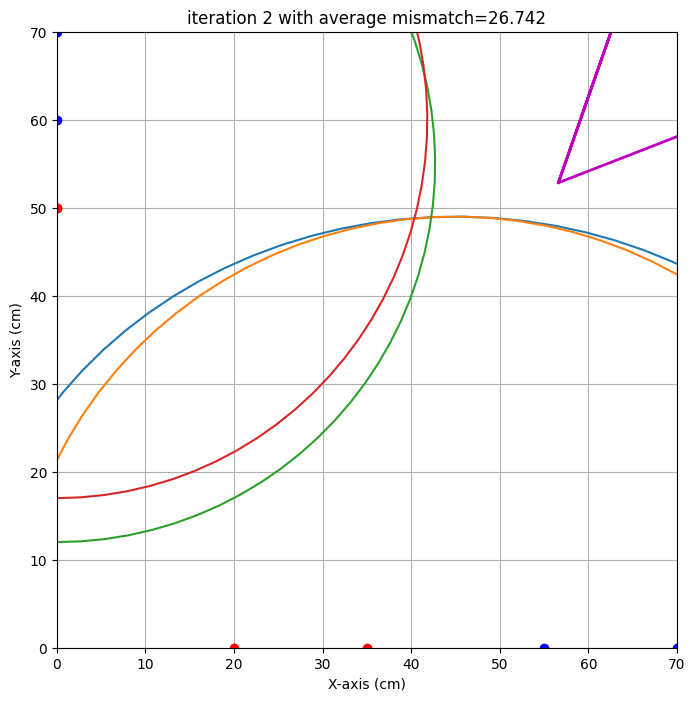

end iteration 2 with average mismatch=26.742


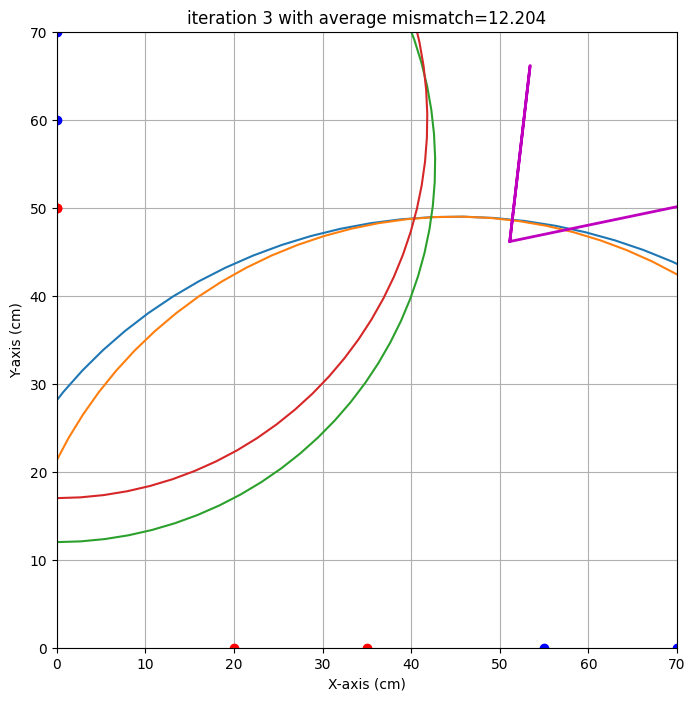

end iteration 3 with average mismatch=12.204


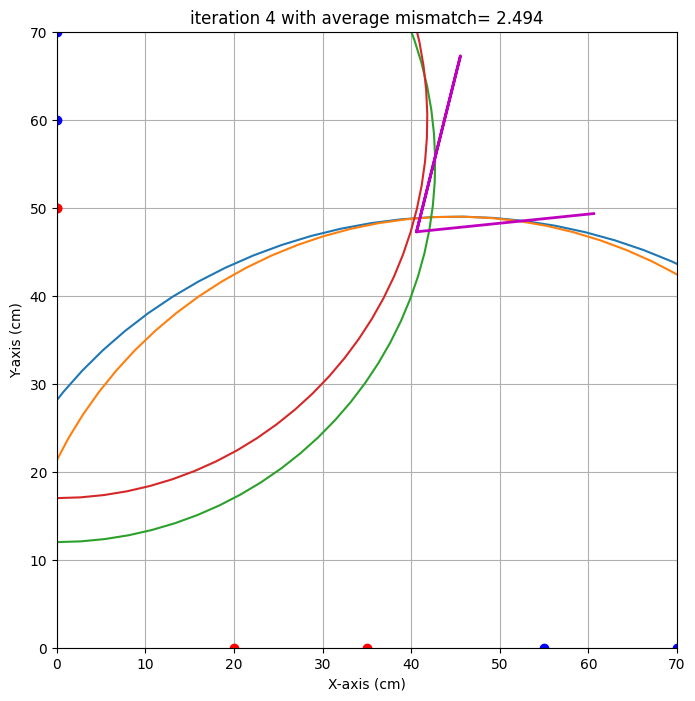

end iteration 4 with average mismatch= 2.494


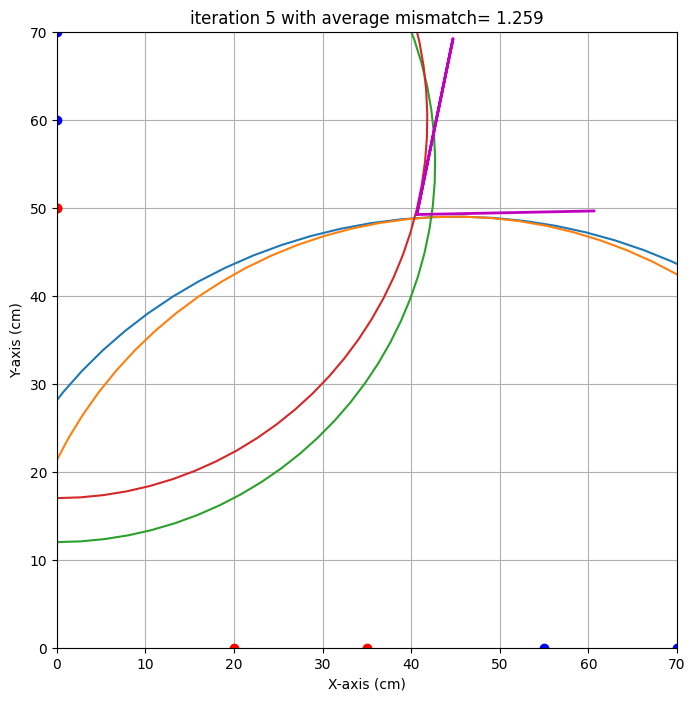

end iteration 5 with average mismatch= 1.259


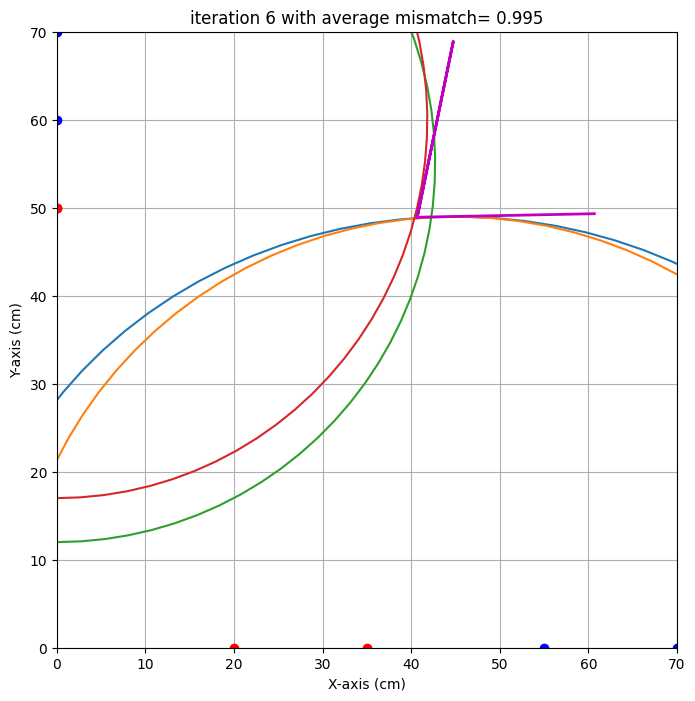

end iteration 6 with average mismatch= 0.995
end iteration 7 with average mismatch= 0.960
end iteration 8 with average mismatch= 0.938
end iteration 9 with average mismatch= 0.938
end iteration 10 with average mismatch= 0.938
end iteration 11 with average mismatch= 0.862
end iteration 12 with average mismatch= 0.860
end iteration 13 with average mismatch= 0.860
end iteration 14 with average mismatch= 0.860
end iteration 15 with average mismatch= 0.860
end iteration 16 with average mismatch= 0.860
end iteration 17 with average mismatch= 0.860
end iteration 18 with average mismatch= 0.860
end iteration 19 with average mismatch= 0.860
end iteration 20 with average mismatch= 0.860
end iteration 21 with average mismatch= 0.860
end iteration 22 with average mismatch= 0.860
end iteration 23 with average mismatch= 0.860
end iteration 24 with average mismatch= 0.860
end iteration 25 with average mismatch= 0.860
end iteration 26 with average mismatch= 0.860
end iteration 27 with average mismatch

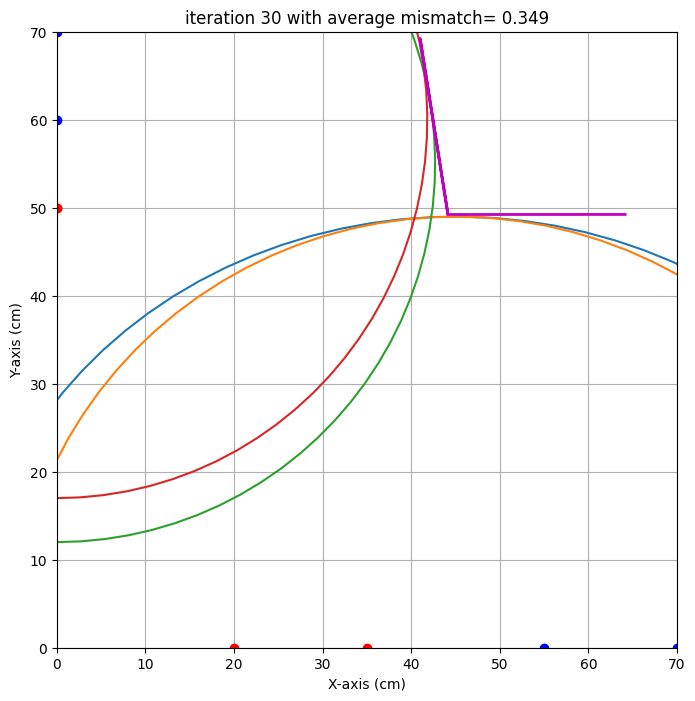

end iteration 30 with average mismatch= 0.349
###############################################################################
end of iteration  30
Best alpha=   0.02 with uncertainty=  14.99
Best beta =  -8.94 with uncertainty=   7.62
Best x0   =  44.15 with uncertainty=   1.31
Best y0   =  49.23 with uncertainty=   1.90
###############################################################################


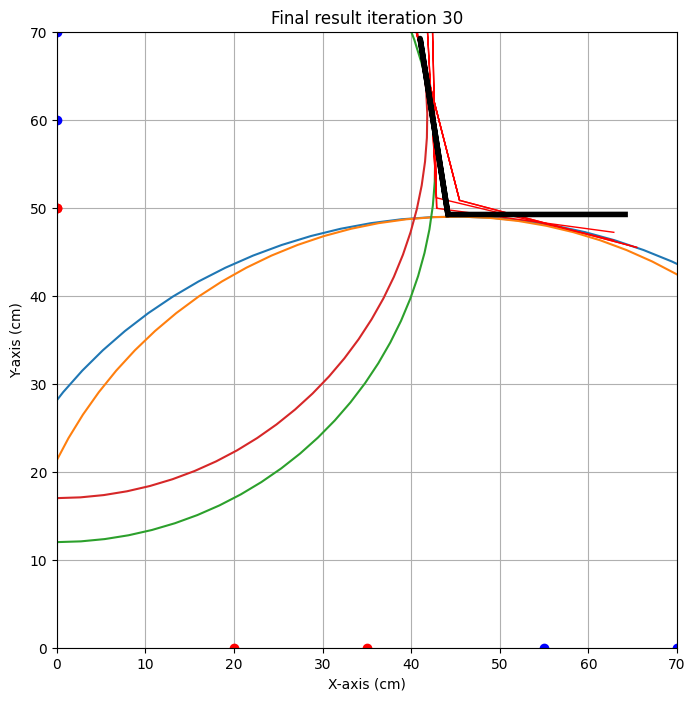

{'alpha': np.float64(0.020448264709166608), 'alpha_eps': np.float64(14.988022350364151), 'beta': np.float64(-8.942827952190791), 'beta_eps': np.float64(7.624834204009598), 'x0': np.float64(44.15236579667648), 'x0_eps': np.float64(1.3082751080399504), 'y0': np.float64(49.22942913328359), 'y0_eps': np.float64(1.8980800415901982)}
Oscar
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  30   0  111
1  30   0  40   0  102
2  40   0  50   0   99
3  50   0  60   0   98
4   0  30   0  40  114
5   0  40   0  50   89
6   0  50   0  60   86


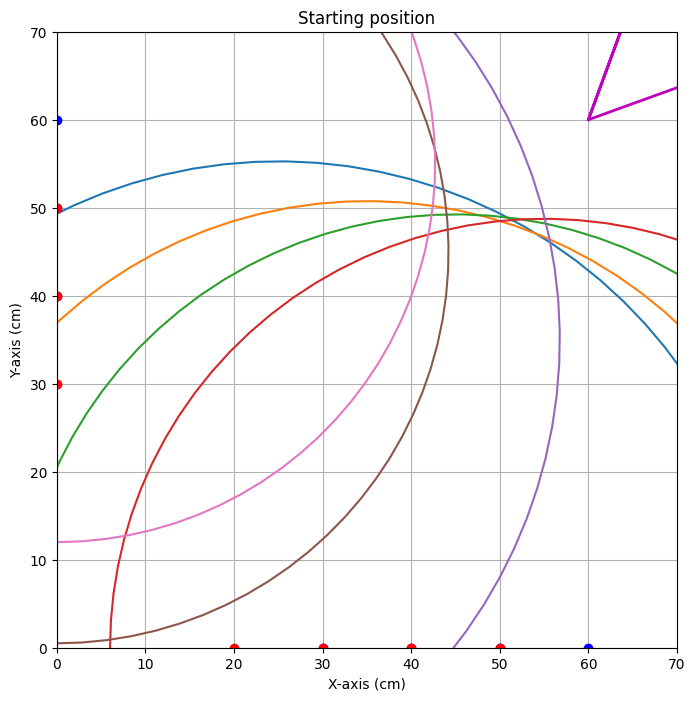


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=33.981


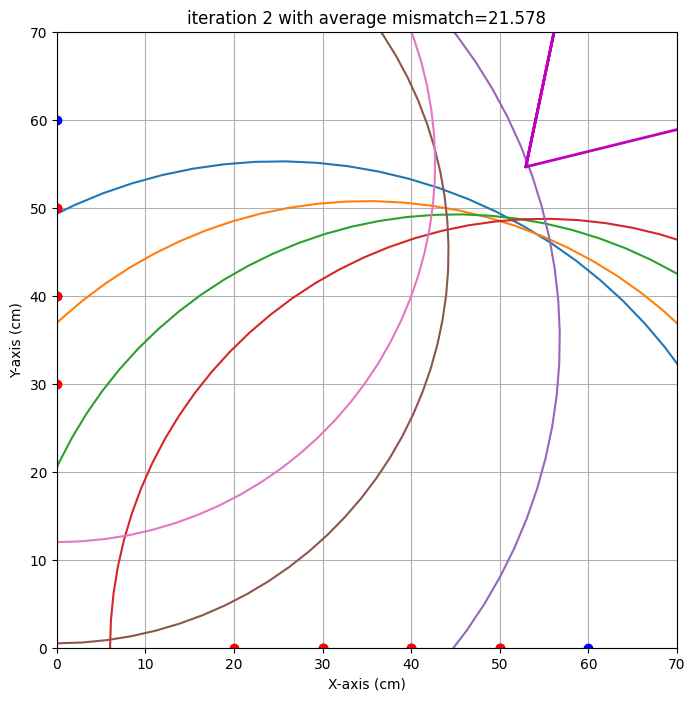

end iteration 2 with average mismatch=21.578


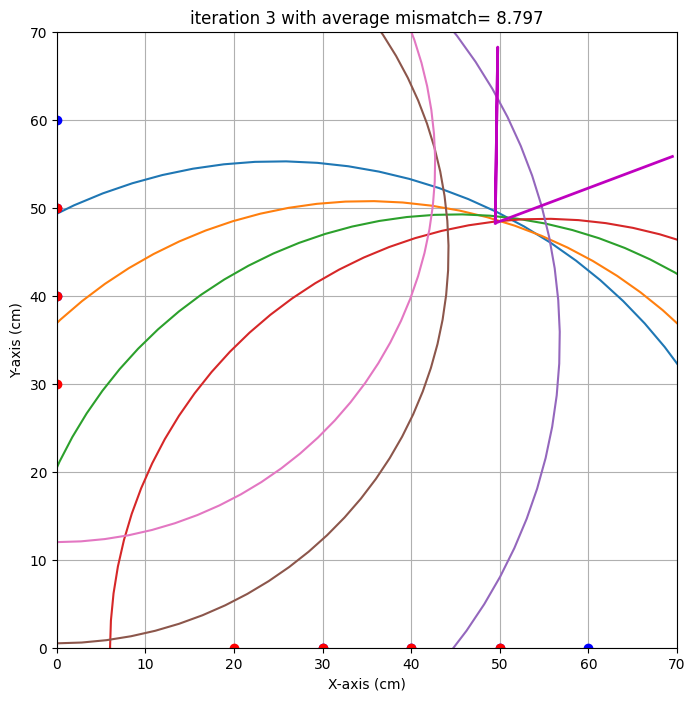

end iteration 3 with average mismatch= 8.797


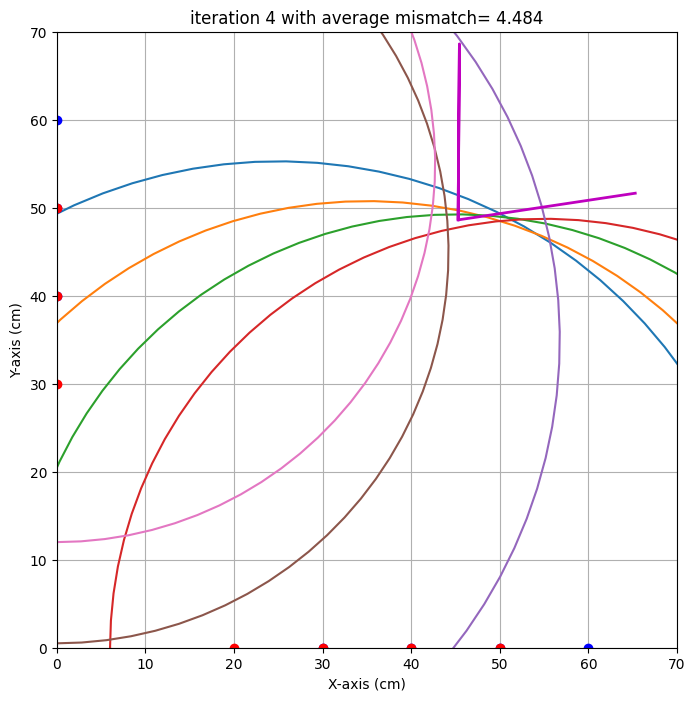

end iteration 4 with average mismatch= 4.484
end iteration 5 with average mismatch= 4.444


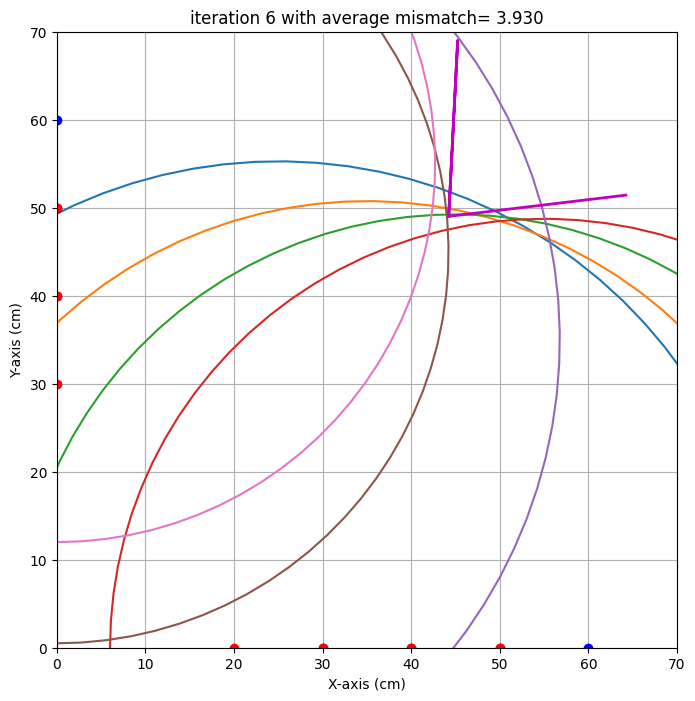

end iteration 6 with average mismatch= 3.930
end iteration 7 with average mismatch= 3.801
end iteration 8 with average mismatch= 3.483


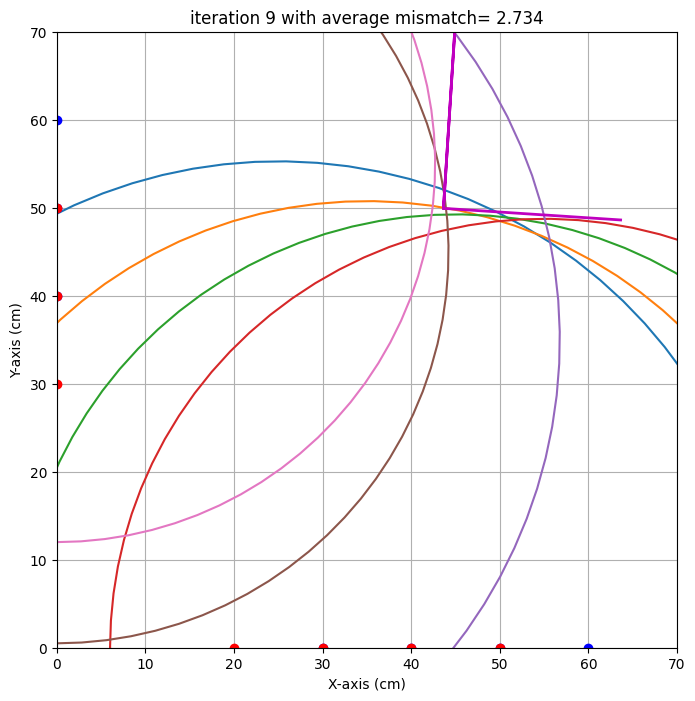

end iteration 9 with average mismatch= 2.734
end iteration 10 with average mismatch= 2.712
end iteration 11 with average mismatch= 2.678
end iteration 12 with average mismatch= 2.654
end iteration 13 with average mismatch= 2.650
end iteration 14 with average mismatch= 2.576
end iteration 15 with average mismatch= 2.576
end iteration 16 with average mismatch= 2.576
end iteration 17 with average mismatch= 2.576
end iteration 18 with average mismatch= 2.576
end iteration 19 with average mismatch= 2.576
end iteration 20 with average mismatch= 2.576
end iteration 21 with average mismatch= 2.520
end iteration 22 with average mismatch= 2.520
end iteration 23 with average mismatch= 2.520
end iteration 24 with average mismatch= 2.520
end iteration 25 with average mismatch= 2.520
end iteration 26 with average mismatch= 2.520
end iteration 27 with average mismatch= 2.520
end iteration 28 with average mismatch= 2.520
end iteration 29 with average mismatch= 2.520
Last iteration, also determine unce

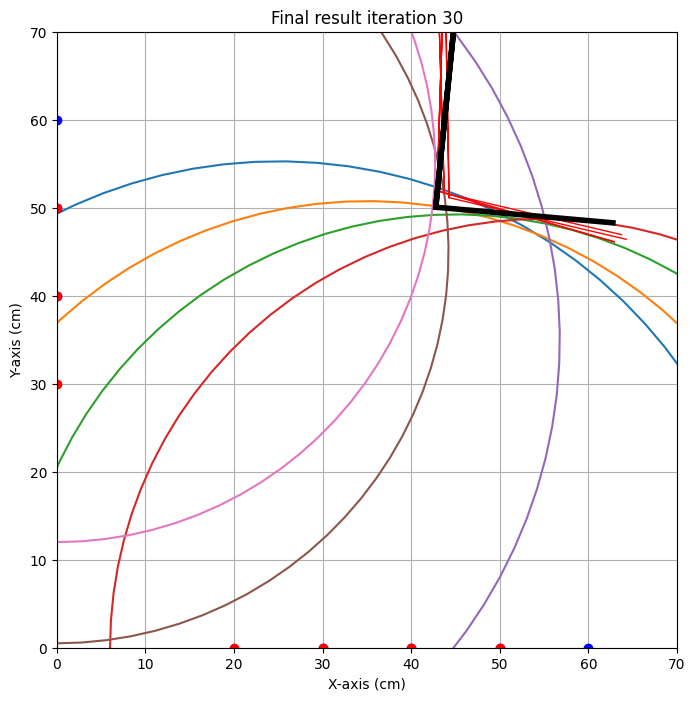

{'alpha': np.float64(-5.0721070326325), 'alpha_eps': np.float64(11.084607923007086), 'beta': np.float64(5.739427584479047), 'beta_eps': np.float64(7.482419823853843), 'x0': np.float64(42.7727827286643), 'x0_eps': np.float64(1.502014135173205), 'y0': np.float64(50.06041415728009), 'y0_eps': np.float64(1.8612031594235248)}
Jochem
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  55   0  65   0  97
1  50   0  60   0  97
2   0  55   0  65  86
3   0  50   0  60  87


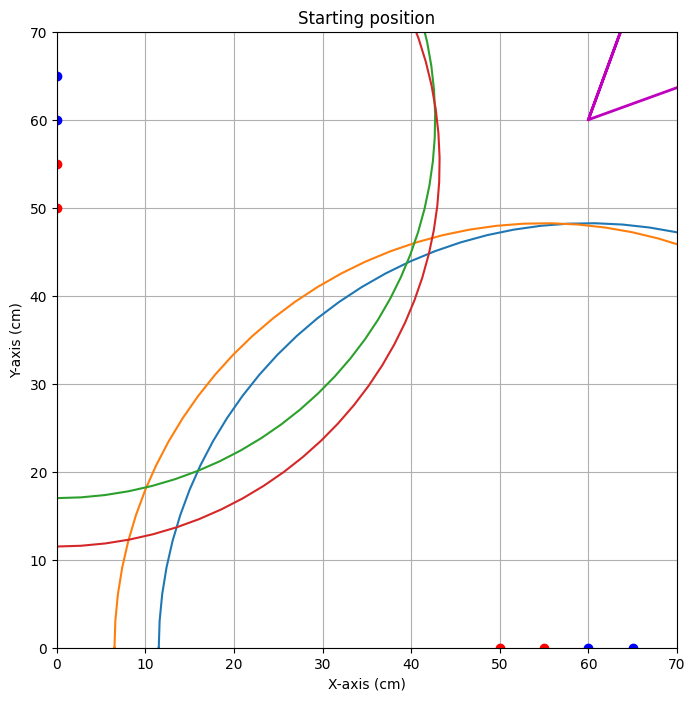


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.405


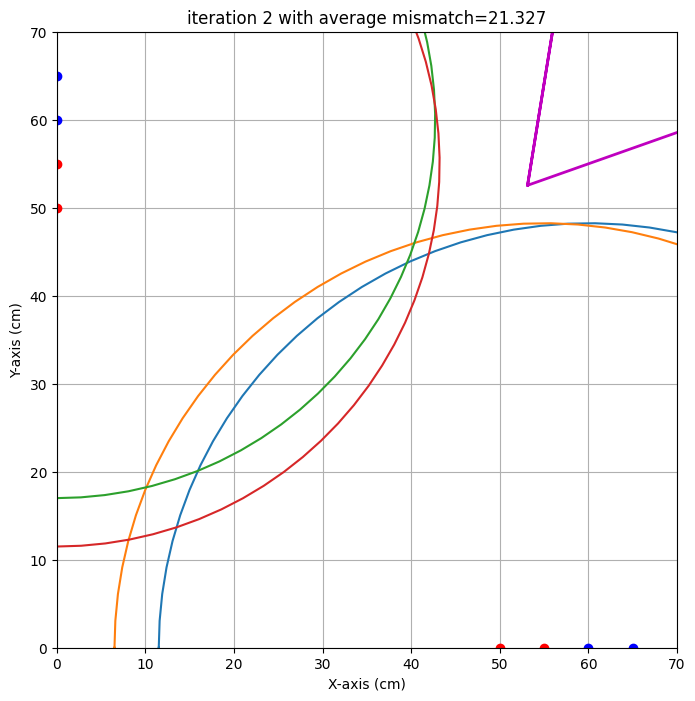

end iteration 2 with average mismatch=21.327


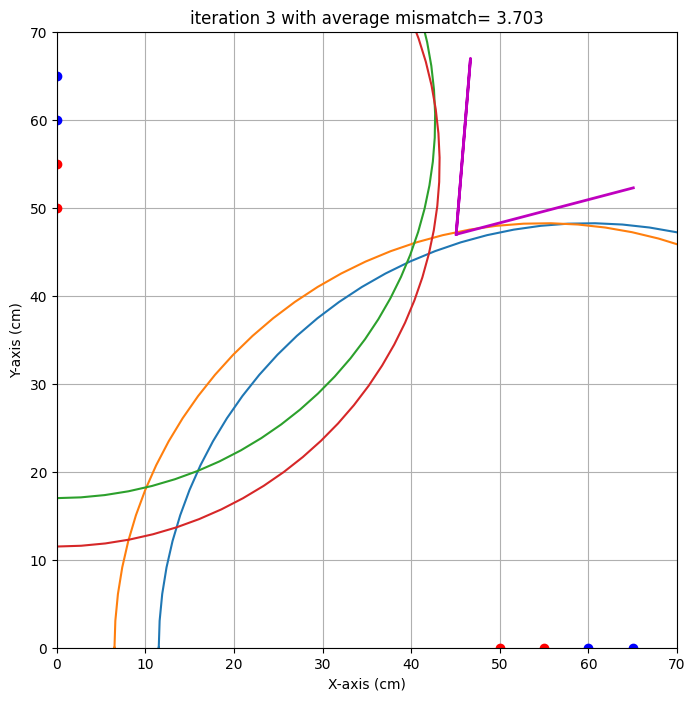

end iteration 3 with average mismatch= 3.703


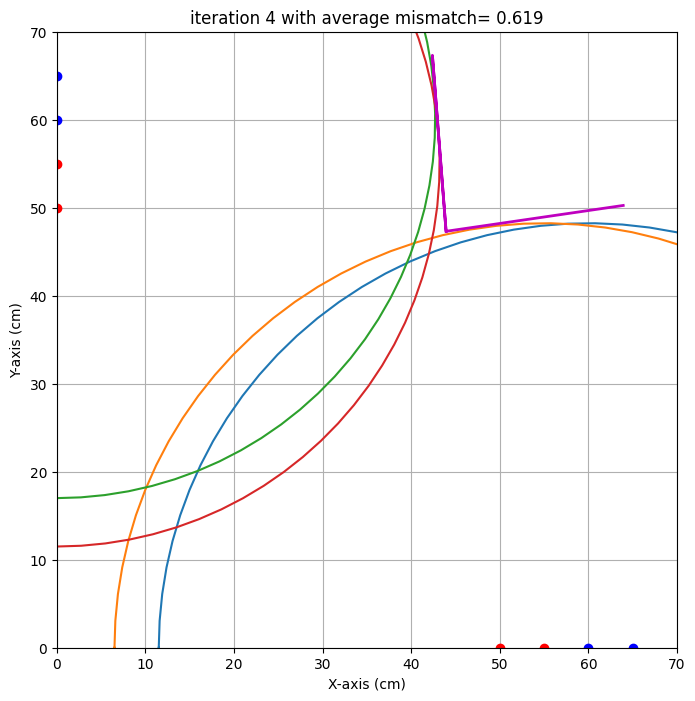

end iteration 4 with average mismatch= 0.619
end iteration 5 with average mismatch= 0.610


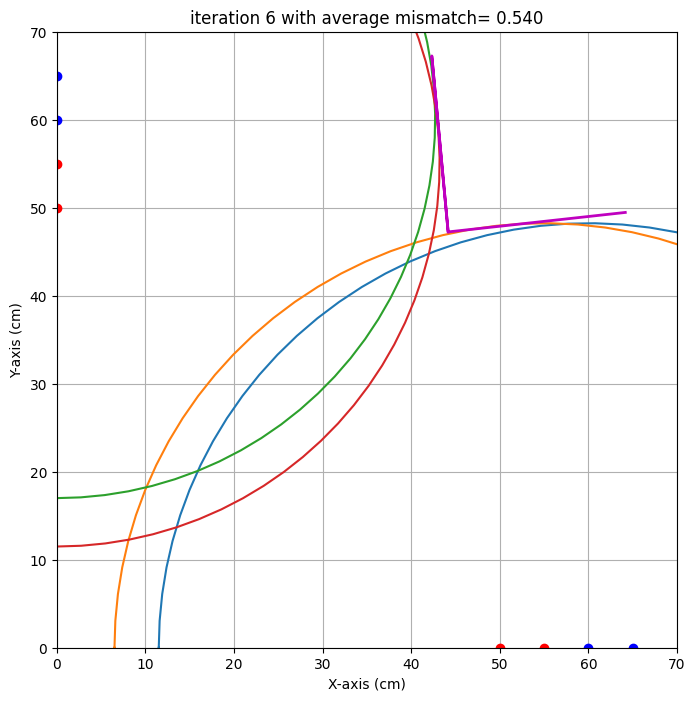

end iteration 6 with average mismatch= 0.540


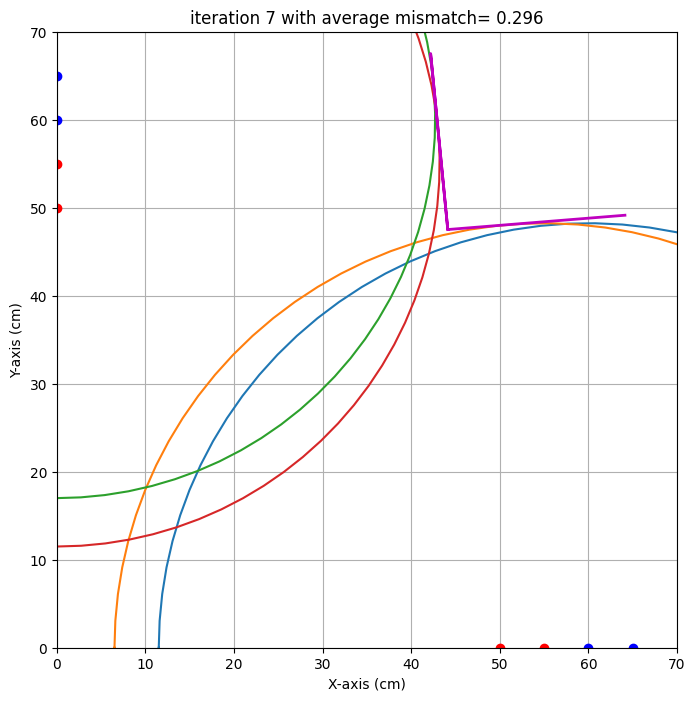

end iteration 7 with average mismatch= 0.296
end iteration 8 with average mismatch= 0.295
end iteration 9 with average mismatch= 0.294
end iteration 10 with average mismatch= 0.281


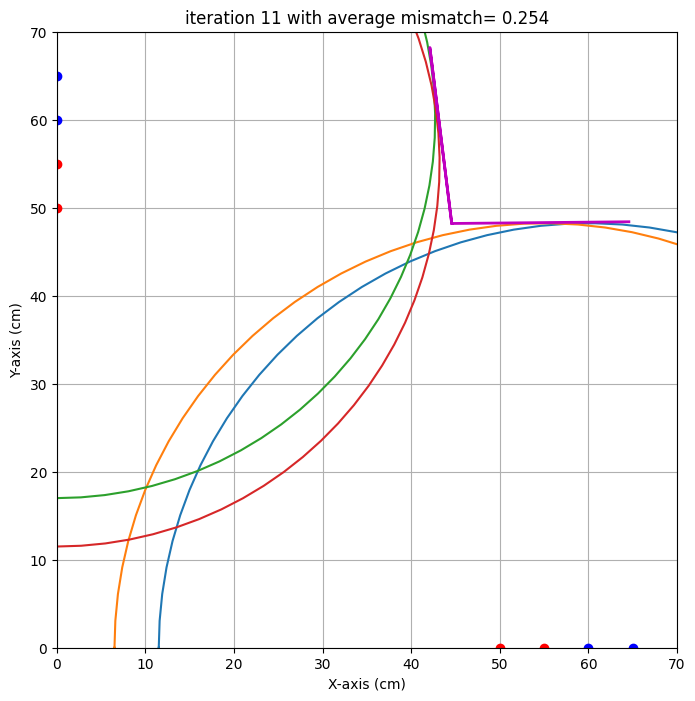

end iteration 11 with average mismatch= 0.254
end iteration 12 with average mismatch= 0.232


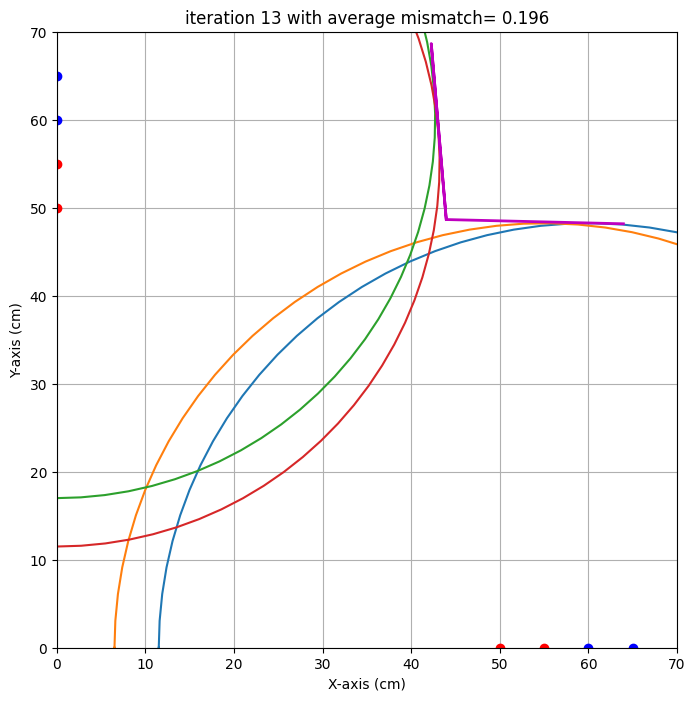

end iteration 13 with average mismatch= 0.196
end iteration 14 with average mismatch= 0.182
end iteration 15 with average mismatch= 0.175
end iteration 16 with average mismatch= 0.173
end iteration 17 with average mismatch= 0.173
end iteration 18 with average mismatch= 0.173
end iteration 19 with average mismatch= 0.173
end iteration 20 with average mismatch= 0.173
end iteration 21 with average mismatch= 0.173
end iteration 22 with average mismatch= 0.173
end iteration 23 with average mismatch= 0.173
end iteration 24 with average mismatch= 0.173
end iteration 25 with average mismatch= 0.173
end iteration 26 with average mismatch= 0.173
end iteration 27 with average mismatch= 0.173
end iteration 28 with average mismatch= 0.173
end iteration 29 with average mismatch= 0.173
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.173
###############################################################

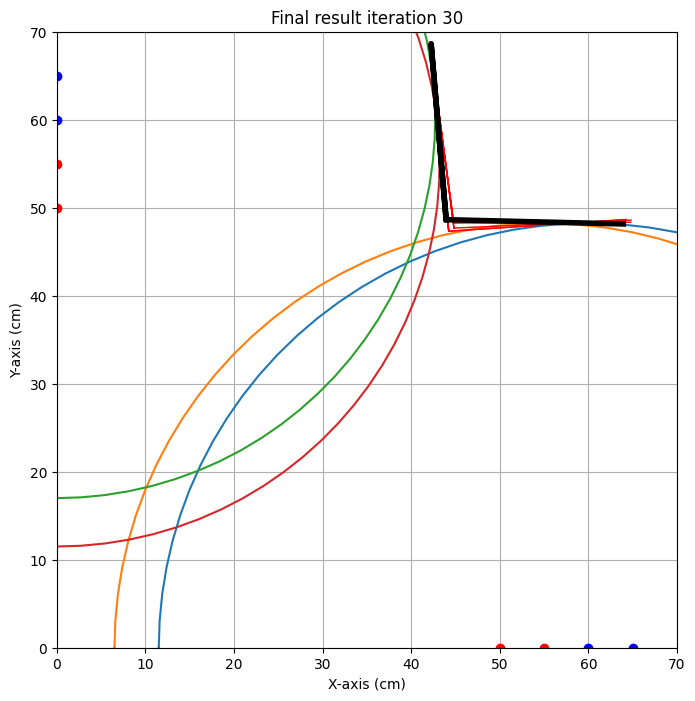

{'alpha': np.float64(-1.3878155160885177), 'alpha_eps': np.float64(5.1780753181403085), 'beta': np.float64(-4.8600919974483405), 'beta_eps': np.float64(2.722955658606712), 'x0': np.float64(43.947944815513), 'x0_eps': np.float64(0.8777624605548553), 'y0': np.float64(48.64147687472602), 'y0_eps': np.float64(1.3094635447140917)}


In [16]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
studentNames = ["luuk", "Oscar", "Jochem"]

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [21]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

luuk 
x0 target is : 45.0. Gevonden waarde: 44.2 cm met een standaardafwijking van 1.3 cm 
y0 target is : 50.0. Gevonden waarde: 49.2 cm met een standaardafwijking van 1.9 cm 
alpha target is : 0.0. Gevonden waarde: 0.0 graden met een standaardafwijking van 15.0 graad 
beta target is : -9.0. Gevonden waarde: -8.9 graden met een standaardafwijking van 7.6 graad 

Oscar 
x0 target is : 45.0. Gevonden waarde: 42.8 cm met een standaardafwijking van 1.5 cm 
y0 target is : 50.0. Gevonden waarde: 50.1 cm met een standaardafwijking van 1.9 cm 
alpha target is : 0.0. Gevonden waarde: -5.1 graden met een standaardafwijking van 11.1 graad 
beta target is : -9.0. Gevonden waarde: 5.7 graden met een standaardafwijking van 7.5 graad 

Jochem 
x0 target is : 45.0. Gevonden waarde: 43.9 cm met een standaardafwijking van 0.9 cm 
y0 target is : 50.0. Gevonden waarde: 48.6 cm met een standaardafwijking van 1.3 cm 
alpha target is : 0.0. Gevonden waarde: -1.4 graden met een standaardafwijking van 5.2 graa

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  20   0  55
1  35   0  20   0  56
2  40   0  20   0  58
3  45   0  20   0  60
4   0  30   0  20  56
5   0  35   0  20  57
6   0  40   0  20  58
7   0  45   0  20  62


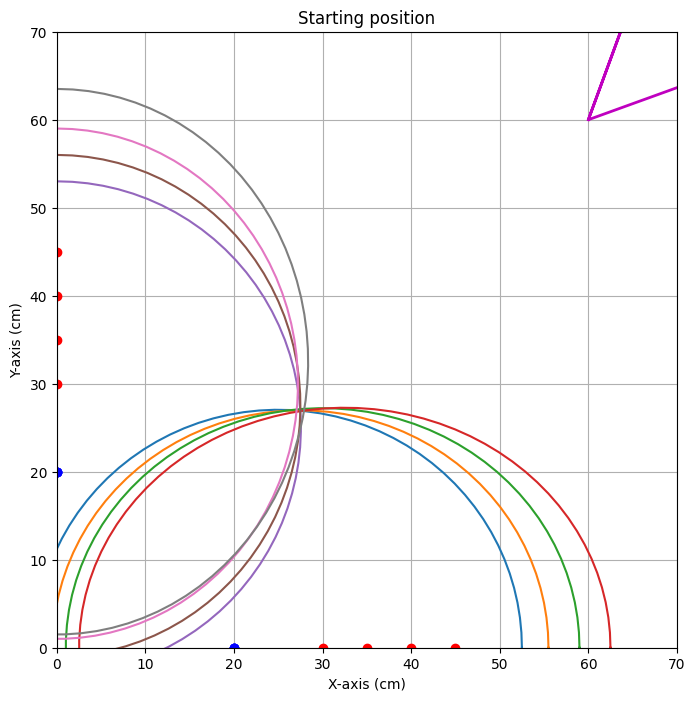


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.852


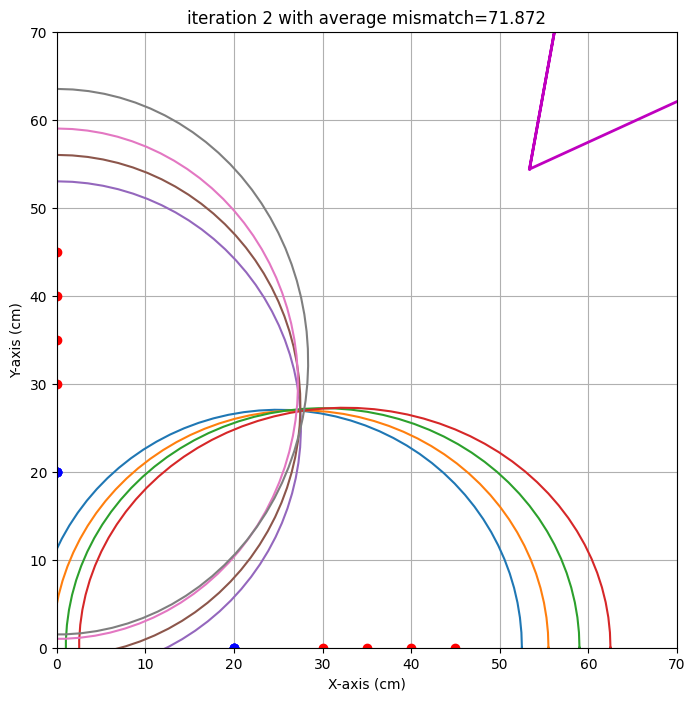

end iteration 2 with average mismatch=71.872


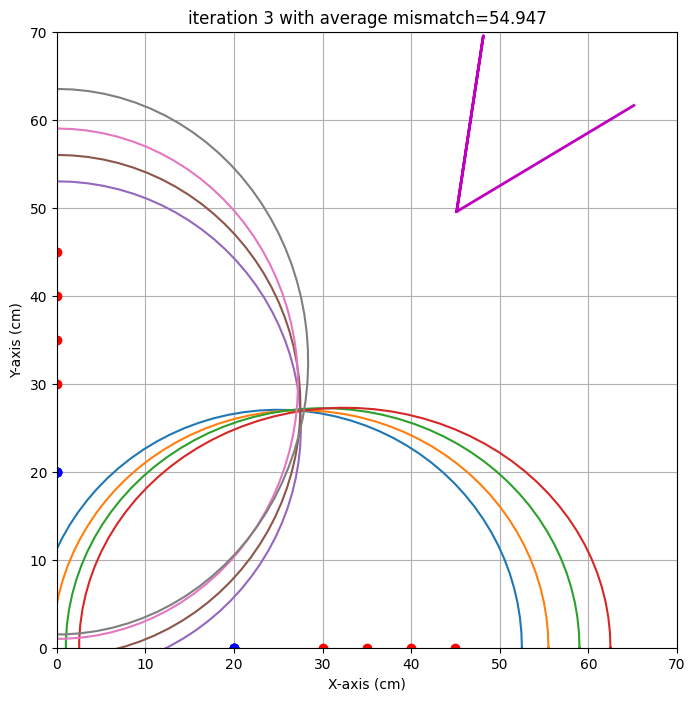

end iteration 3 with average mismatch=54.947


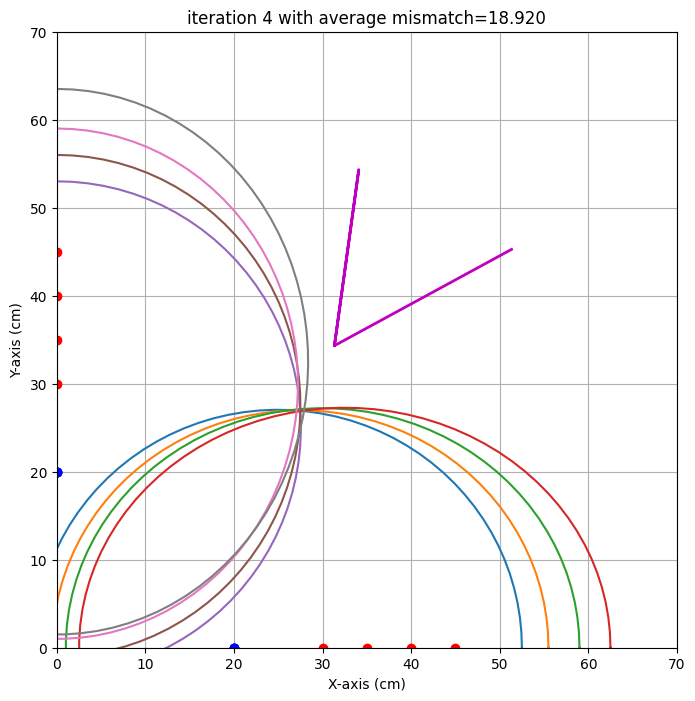

end iteration 4 with average mismatch=18.920


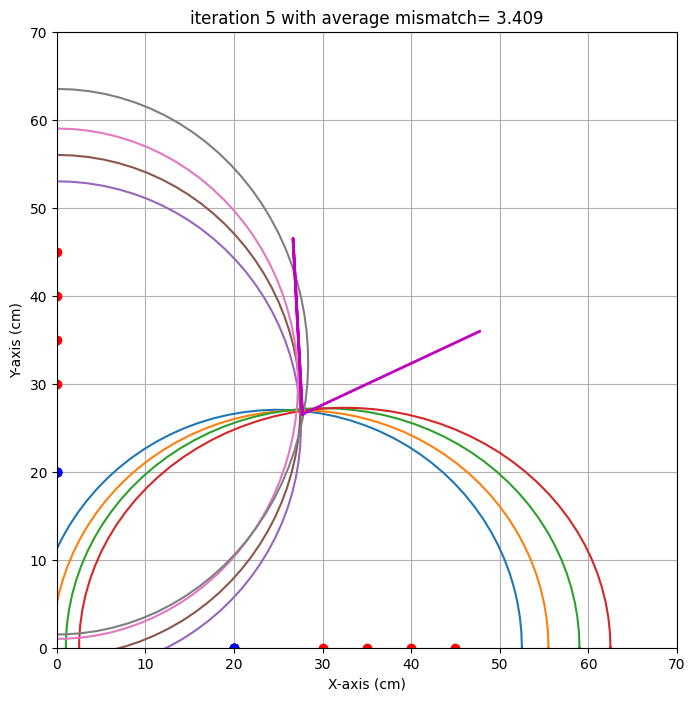

end iteration 5 with average mismatch= 3.409


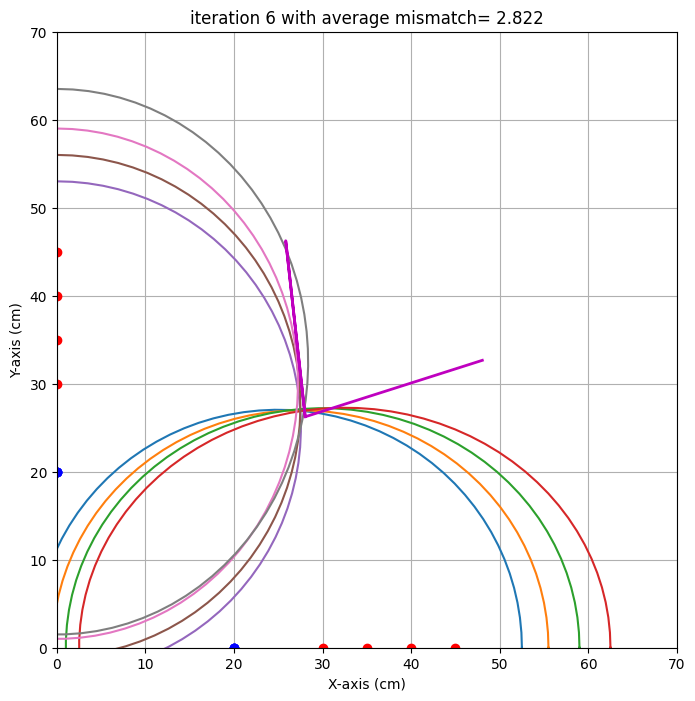

end iteration 6 with average mismatch= 2.822


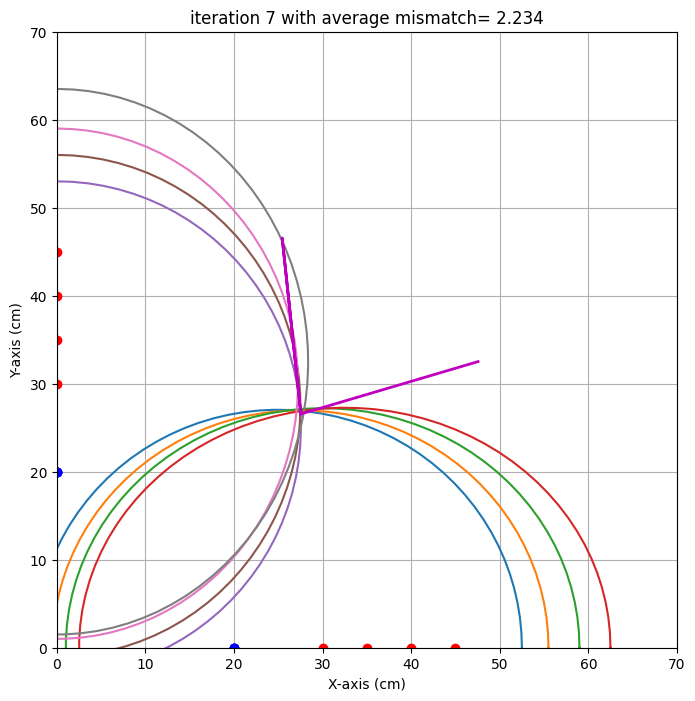

end iteration 7 with average mismatch= 2.234
end iteration 8 with average mismatch= 2.204
end iteration 9 with average mismatch= 2.204
end iteration 10 with average mismatch= 2.118
end iteration 11 with average mismatch= 2.094


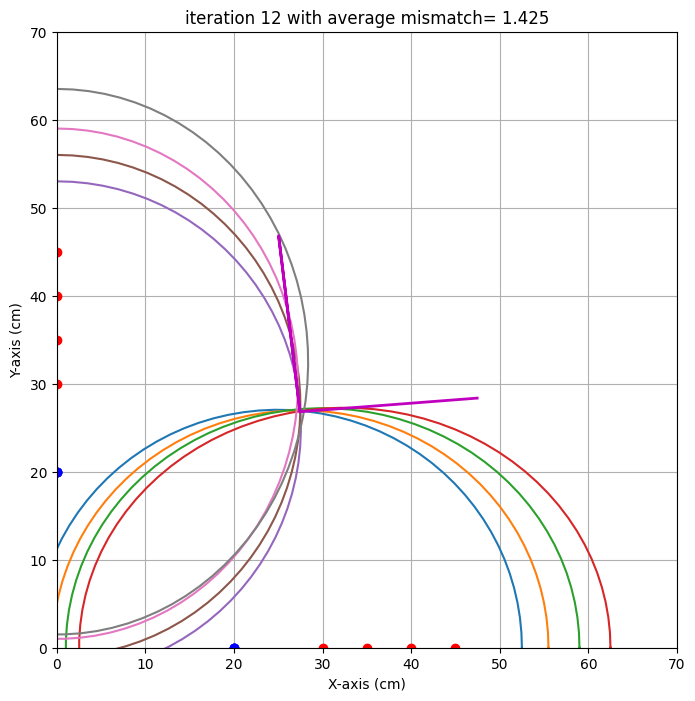

end iteration 12 with average mismatch= 1.425
end iteration 13 with average mismatch= 1.376


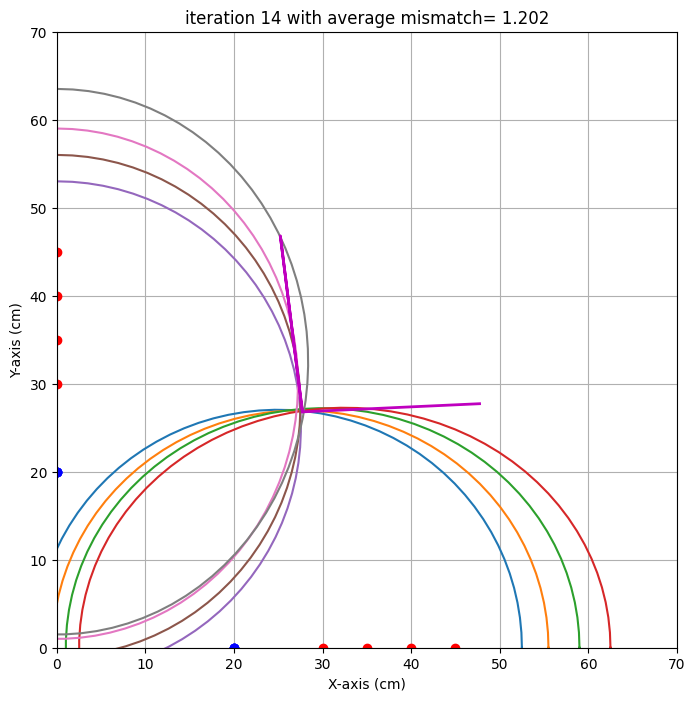

end iteration 14 with average mismatch= 1.202
end iteration 15 with average mismatch= 1.168
end iteration 16 with average mismatch= 1.168
end iteration 17 with average mismatch= 1.168
end iteration 18 with average mismatch= 1.168
end iteration 19 with average mismatch= 1.168
end iteration 20 with average mismatch= 1.148
end iteration 21 with average mismatch= 1.148


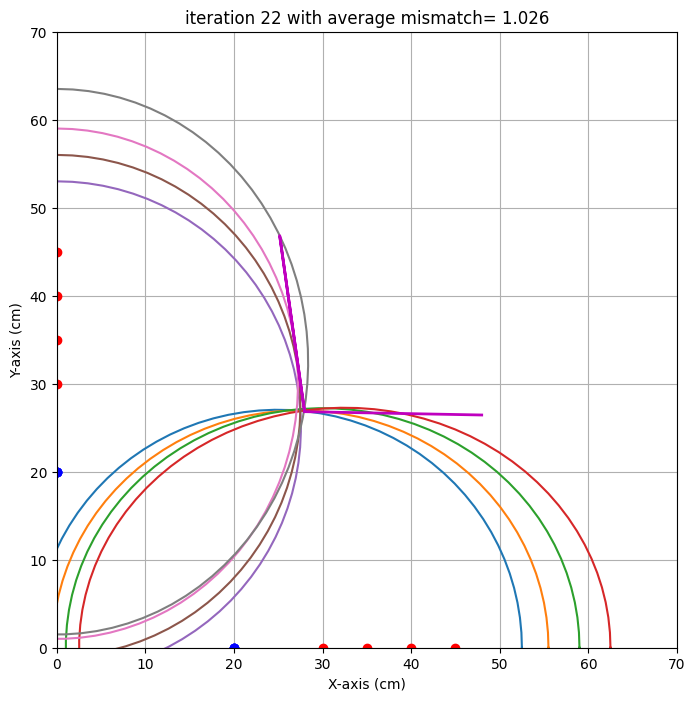

end iteration 22 with average mismatch= 1.026
end iteration 23 with average mismatch= 1.025
end iteration 24 with average mismatch= 1.025
end iteration 25 with average mismatch= 1.025
end iteration 26 with average mismatch= 1.025
end iteration 27 with average mismatch= 1.025
end iteration 28 with average mismatch= 1.025
end iteration 29 with average mismatch= 1.025
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


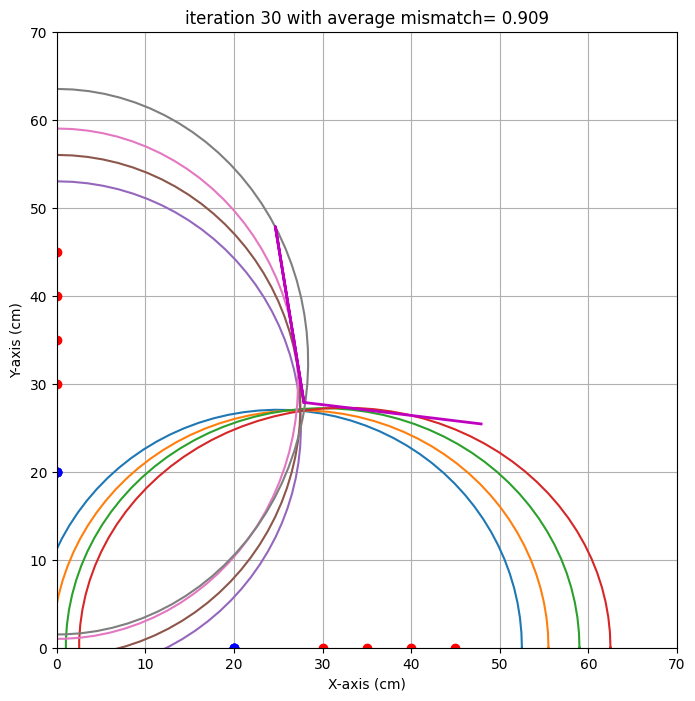

end iteration 30 with average mismatch= 0.909
###############################################################################
end of iteration  30
Best alpha=  -6.97 with uncertainty=   0.44
Best beta =  -9.17 with uncertainty=   1.24
Best x0   =  27.89 with uncertainty=   0.24
Best y0   =  27.87 with uncertainty=   0.22
###############################################################################


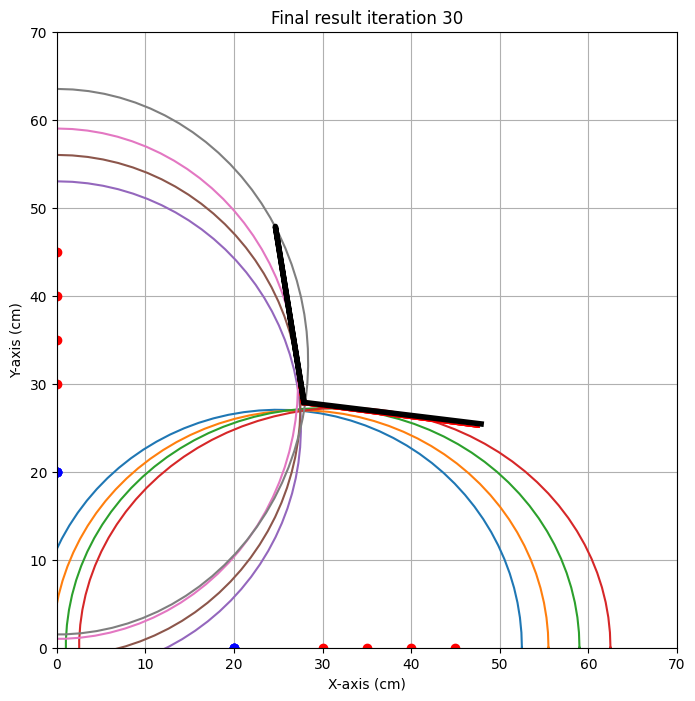

{'alpha': np.float64(-6.966901711650271), 'alpha_eps': np.float64(0.4397274597275258), 'beta': np.float64(-9.173513178385708), 'beta_eps': np.float64(1.2391993827628873), 'x0': np.float64(27.892745711593733), 'x0_eps': np.float64(0.24245072047978056), 'y0': np.float64(27.87495813925908), 'y0_eps': np.float64(0.21997379538199624)}
locatie 1 
x0 target is : 28.0. Gevonden waarde: 27.9 cm met een standaardafwijking van 0.2 cm 
y0 target is : 25.0. Gevonden waarde: 27.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 3.0. Gevonden waarde: -7.0 graden met een standaardafwijking van 0.4 graad 
beta target is : -8.0. Gevonden waarde: -9.2 graden met een standaardafwijking van 1.2 graad 



In [27]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':28,#zelf aanvullen,
                    'y0':25,#zelf aanvullen,
                    'alpha' :3 ,#zelf aanvullen,
                    'beta' :-8 ,#zelf aanvullen},
           'locatie 2':{'x0': 43,#zelf aanvullen,
                    'y0':30,#zelf aanvullen,
                    'alpha' : 0,#zelf aanvullen,
                    'beta' : 0}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,20,0,55],
    [35,0,20,0,56],
    [40,0,20,0,58],
    [45,0,20,0,60],
    [0,30,0,20,56],
    [0,35,0,20,57],
    [0,40,0,20,58],
    [0,45,0,20,62],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,30,0,68],
    [50,0,40,0,61],
    [55,0,40,0,62],
    [0,40,0,30,84],
    [0,45,0,30,85],
    [0,50,0,30,86],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  40   0  85
1  55   0  40   0  86
2  60   0  40   0  89
3  50   0  60   0  90
4   0  40   0  30  70
5   0  50   0  35  68
6   0  50   0  40  66


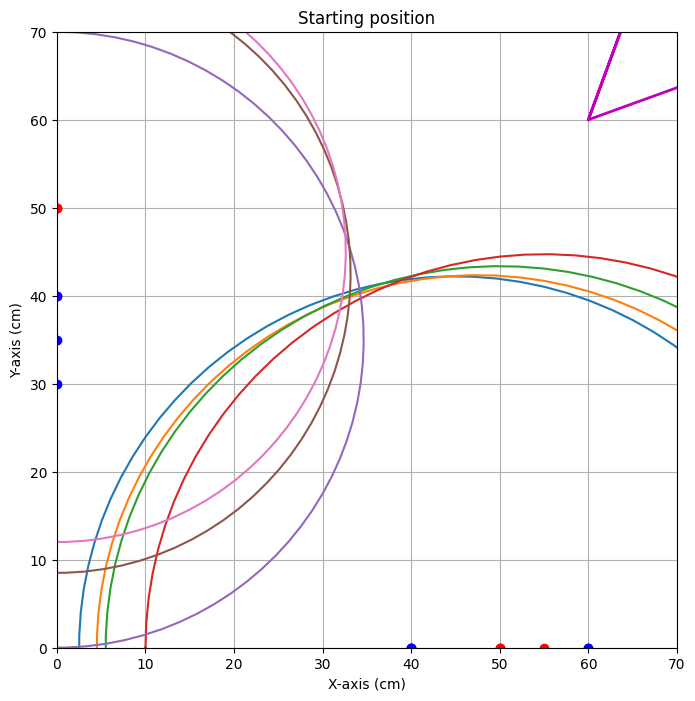


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.433


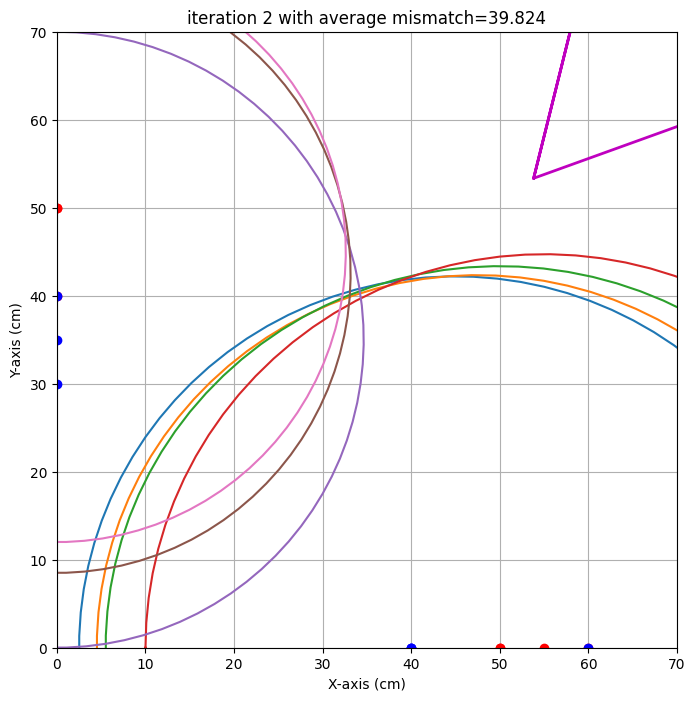

end iteration 2 with average mismatch=39.824


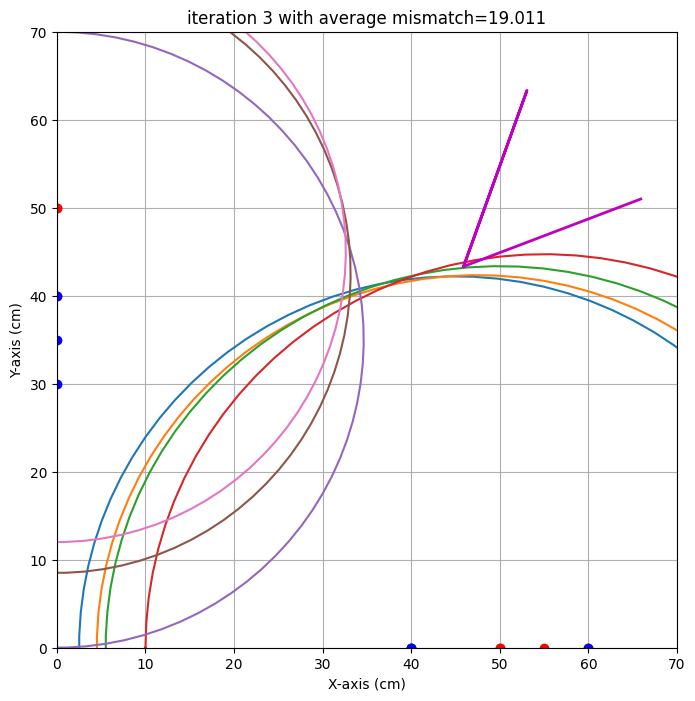

end iteration 3 with average mismatch=19.011


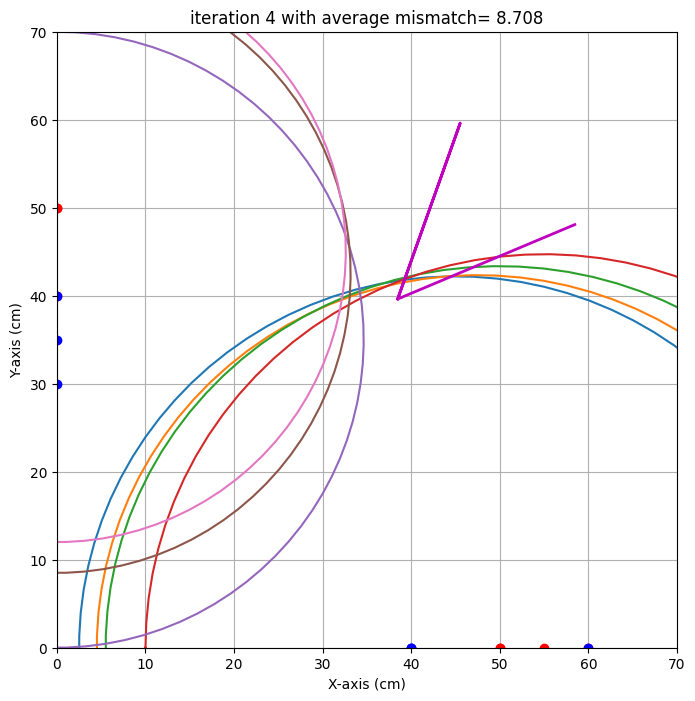

end iteration 4 with average mismatch= 8.708


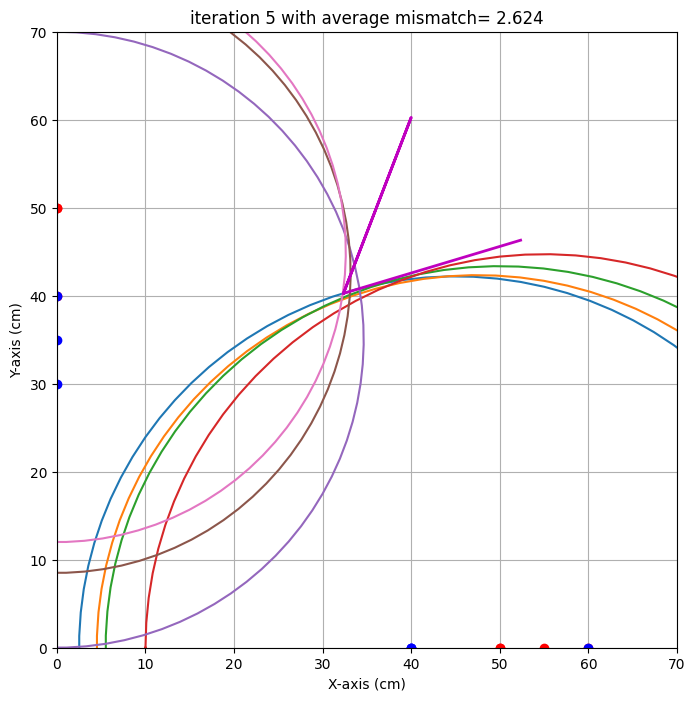

end iteration 5 with average mismatch= 2.624


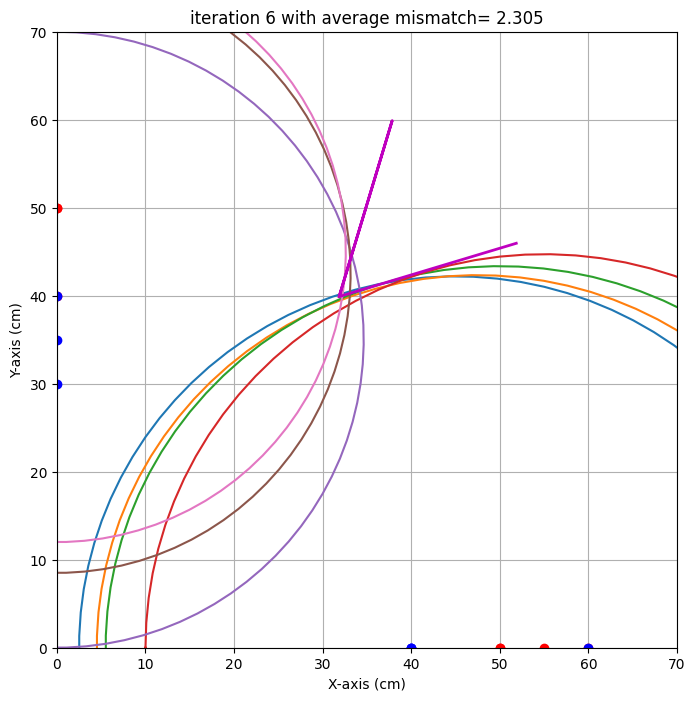

end iteration 6 with average mismatch= 2.305


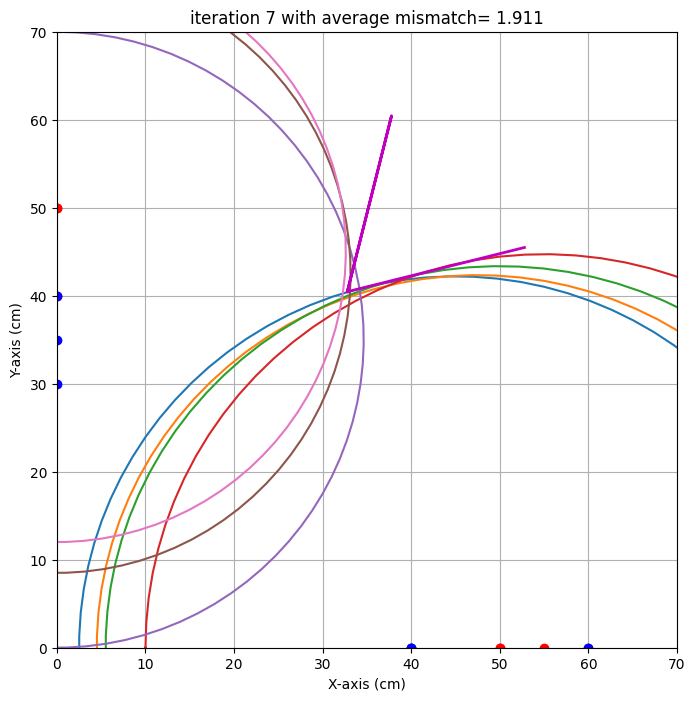

end iteration 7 with average mismatch= 1.911
end iteration 8 with average mismatch= 1.891


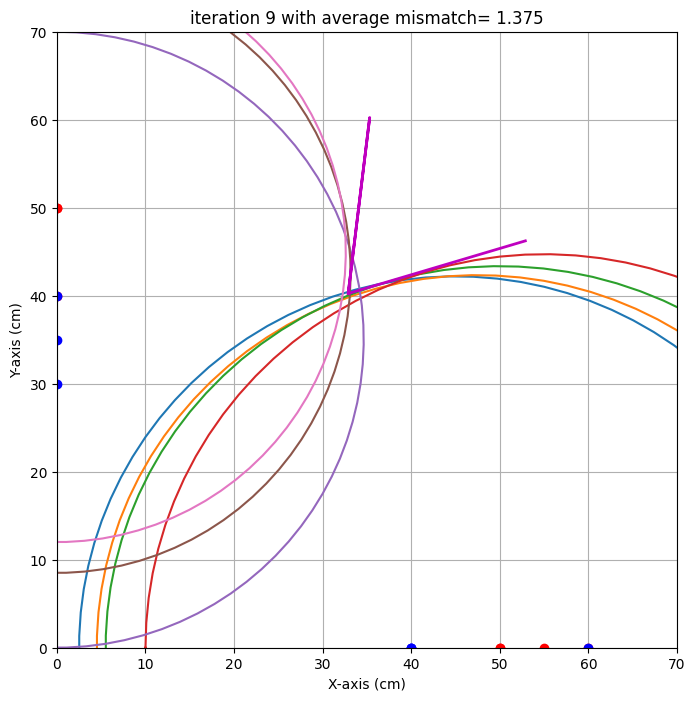

end iteration 9 with average mismatch= 1.375
end iteration 10 with average mismatch= 1.293


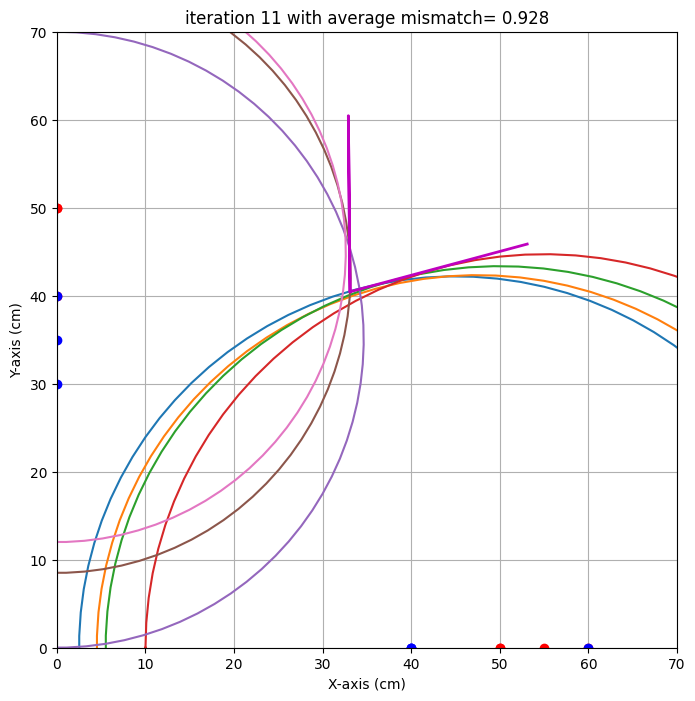

end iteration 11 with average mismatch= 0.928
end iteration 12 with average mismatch= 0.928
end iteration 13 with average mismatch= 0.928
end iteration 14 with average mismatch= 0.928


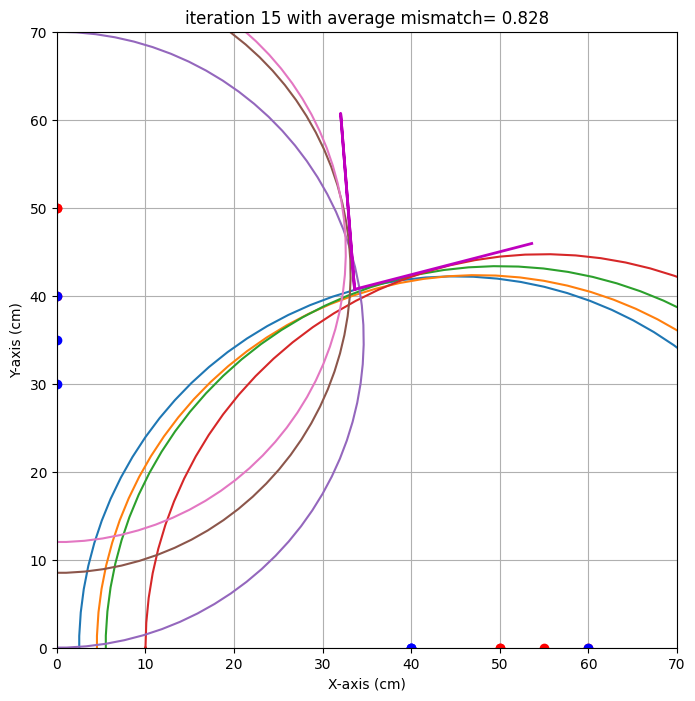

end iteration 15 with average mismatch= 0.828


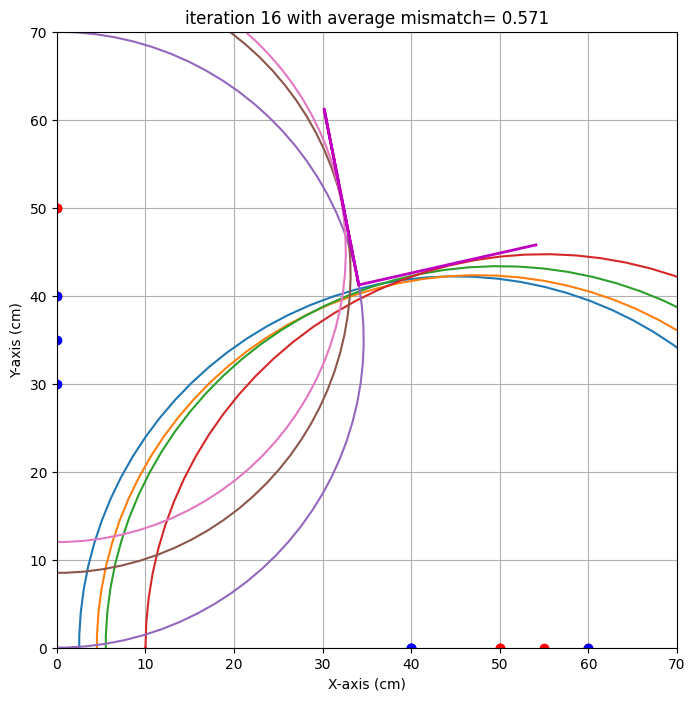

end iteration 16 with average mismatch= 0.571
end iteration 17 with average mismatch= 0.566
end iteration 18 with average mismatch= 0.560


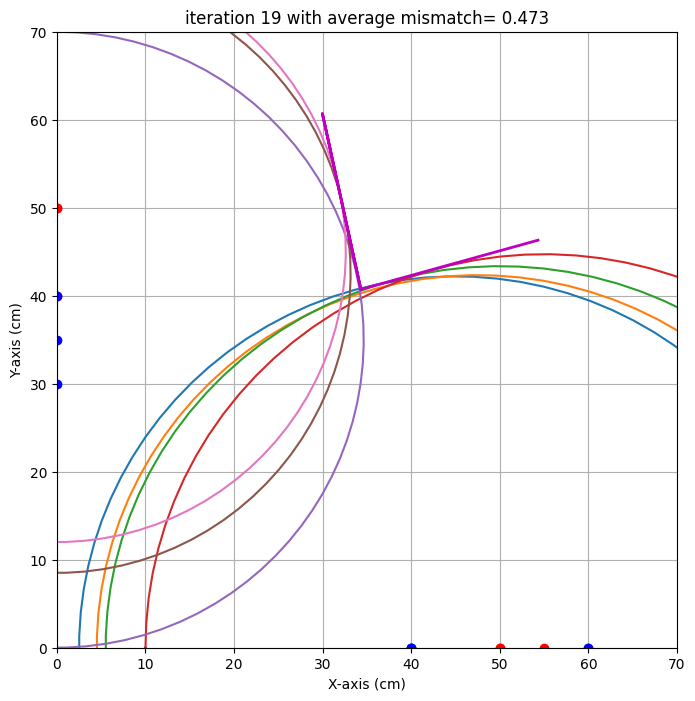

end iteration 19 with average mismatch= 0.473
end iteration 20 with average mismatch= 0.472
end iteration 21 with average mismatch= 0.472


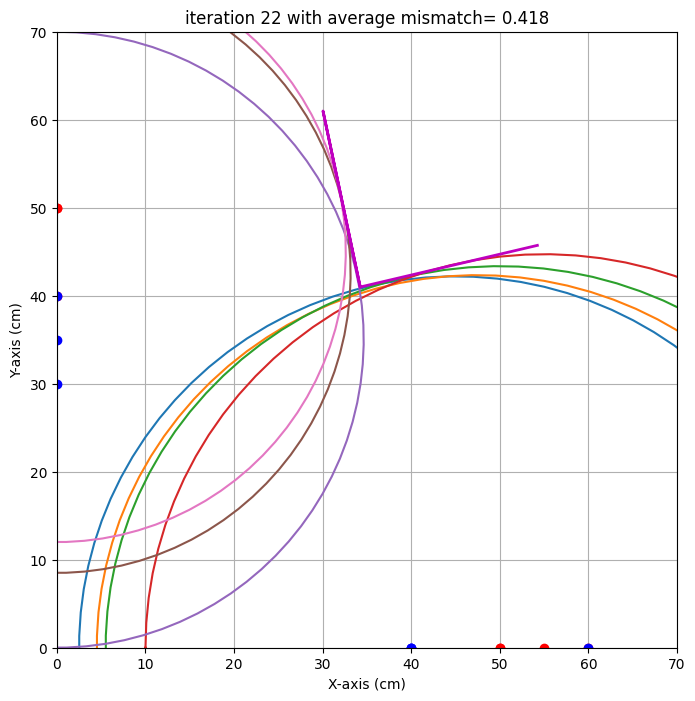

end iteration 22 with average mismatch= 0.418
end iteration 23 with average mismatch= 0.412
end iteration 24 with average mismatch= 0.412
end iteration 25 with average mismatch= 0.412
end iteration 26 with average mismatch= 0.412
end iteration 27 with average mismatch= 0.411
end iteration 28 with average mismatch= 0.411
end iteration 29 with average mismatch= 0.398
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.395
###############################################################################
end of iteration  30
Best alpha=  13.74 with uncertainty=   0.74
Best beta = -10.57 with uncertainty=   2.37
Best x0   =  34.14 with uncertainty=   0.47
Best y0   =  40.88 with uncertainty=   0.23
###############################################################################


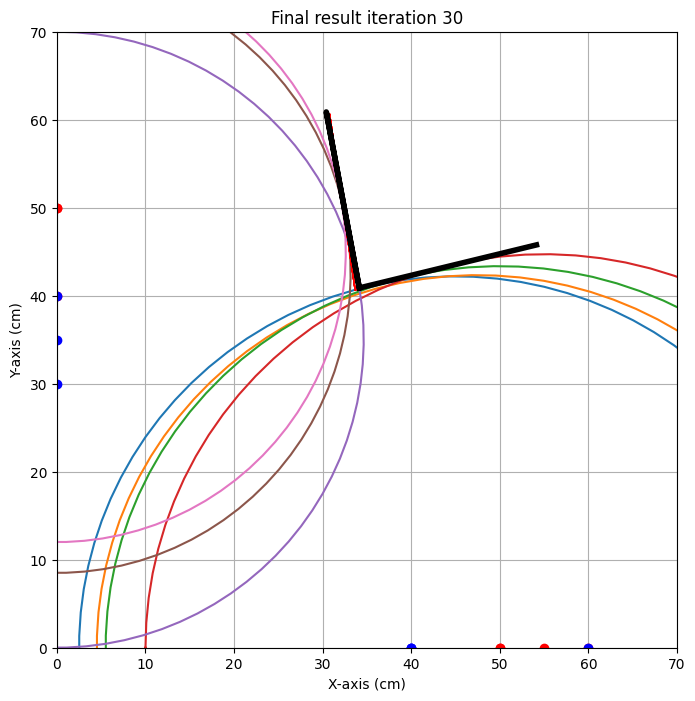

{'alpha': np.float64(13.739783903427083), 'alpha_eps': np.float64(0.7389784792301395), 'beta': np.float64(-10.57120165574679), 'beta_eps': np.float64(2.3687654614092395), 'x0': np.float64(34.143148766629615), 'x0_eps': np.float64(0.47209093910896627), 'y0': np.float64(40.88406211727437), 'y0_eps': np.float64(0.22873633905675206)}
test locatie 
x0 target is : 35.0. Gevonden waarde: 34.1 cm met een standaardafwijking van 0.5 cm 
y0 target is : 40.0. Gevonden waarde: 40.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 16.0. Gevonden waarde: 13.7 graden met een standaardafwijking van 0.7 graad 
beta target is : -11.0. Gevonden waarde: -10.6 graden met een standaardafwijking van 2.4 graad 



In [28]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 35, # zelf aanvullen,
                    'y0': 40, # zelf aanvullen,
                    'alpha':16,  # zelf aanvullen,
                    'beta':-11,   # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#30,0,20,0,164  ,                  
#40,0,30,0,103, 
[50,0,40,0,85],
[55,0,40,0,86],
[60,0,40,0,89], 
[50,0,60,0,90], 
#0,30,0,20,1112   
[0,40,0,30,70],
#0,45,0,30,71 
#0,50,0,30,70
[0,50,0,35,68],  
[0,50,0,40,66],                ])             }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")
*oscar voeg hier algoritme luuk toe*

Luuk:
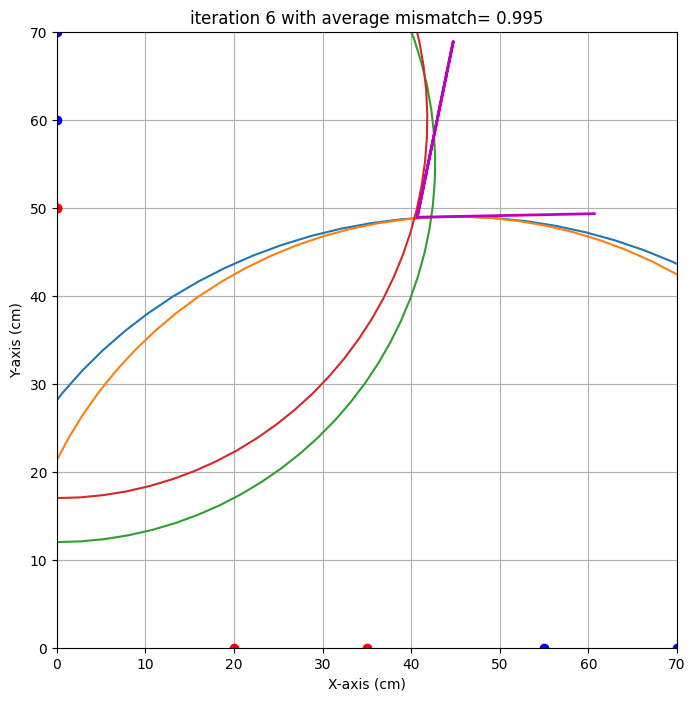
Bij dit algoritme is slim gebruik gemaakt van de afstanden gegeven door de arduino, hierdoor scheelde dit een extra stap op de y-as. Dit werkte in de praktijk zoals verwacht. Op de x-as is gebruik gemaakt van gokken. Het resultaat was binnen de foutmarges.


Figuur: ![Alt](tudelftLogo.png "Title")
*oscar v

Figuur: ![Alt](tudelftLogo.png "Title")
*oscar voeg hier het algoritme toe van jochem*

Jochem:
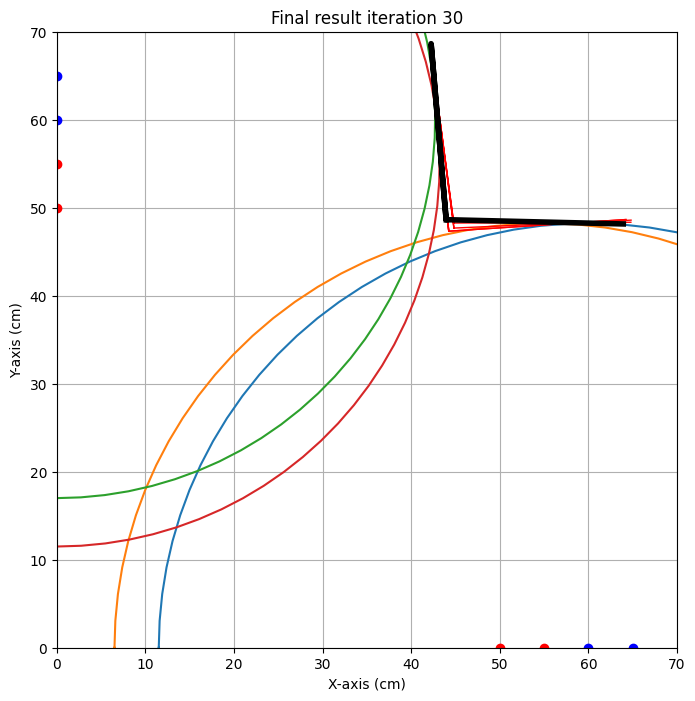

Bij dit algoritme is gebruik gemaakt van kansen, door te kijken of het karton niet toevallig op de lijn tussen de sensoren ligt, of links en rechts van de lijn. Hoeveel metingen je moet doen hangt dus af van welke kant van de lijn je kiest om te gaan meten na de eerste meting. In ons geval hebben we de goede kant gekozen en hierbij een resultaat behaald binnen de marges. Dus we hebben ook bij dit algoritme een geslaagd resultaat.